# 📈 OPIM 5641 Final Project: Advanced Portfolio Optimization
### From Womack → S&P 500 Top 100 → Integer Programming + XGBoost Signal Engine

**University of Connecticut | OPIM 5641: Business Decision Modeling**

---

## 🗺️ Roadmap

| Section | Description |
|---------|-------------|
| **Part 0** | Setup & Installation |
| **Part 1** | Womack Foundation Model (5 stocks, review) |
| **Part 2** | Real S&P 500 Data Pipeline (Top 100 → 10 stocks) |
| **Part 3** | Model 1: Integer Pyomo/Bonmin with Full Constraints |
| **Part 4** | Moving Average Signal Filters (5, 10, 15-day) |
| **Part 5** | Model 2: XGBoost Return Predictor + Constrained Allocation |
| **Part 6** | Sliding Window Backtester (5-day rebalancing) |
| **Part 7** | Benchmark vs. S&P 500 Buy & Hold |
| **Part 8** | Validation Suite & Constraint Report |

---

### Notebook Overview
> *Think of this project in three layers. The **inner layer** is the optimization math — Pyomo builds a MINLP (Mixed Integer Nonlinear Program) that maximizes the Sharpe ratio. The **middle layer** is intelligence — XGBoost predicts which stocks are likely to go up tomorrow, and the moving averages act as traffic lights (green = trending up = eligible to be selected). The **outer layer** is the production machine — the 5-day sliding window simulates what a real quant desk does at 4 PM every Friday: look at the last window, optimize, place orders. Nail these three layers and you have a real production system.*

# ⚙️ Part 0: Setup & Installation

In [1]:
%%capture
import sys, os

# Install Bonmin solver (MINLP-capable)
if 'google.colab' in sys.modules:
    !pip install idaes-pse --pre -q
    !idaes get-extensions --to ./bin
    os.environ['PATH'] += ':bin'

!pip install pyomo yfinance xgboost scikit-learn scipy matplotlib seaborn pandas numpy plotly -q


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import yfinance as yf
import warnings, time, shutil
from datetime import datetime, timedelta
from pyomo.environ import *
from pyomo.opt import TerminationCondition
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize as scipy_minimize

# Pyomo also exports a function named display when using import *.
# Restore notebook-friendly display for pandas tables.
try:
    from IPython.display import display as notebook_display
except Exception:
    def notebook_display(obj):
        try:
            print(obj.to_string())
        except Exception:
            print(obj)
display = notebook_display

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Project constants.  The model trains only on data before the date being tested.
FORWARD_TEST_START = pd.Timestamp('2026-04-21')
LOOKBACK_DAYS = 60
REBALANCE_FREQUENCY = 1      # daily rebalancing for the forward-test period
N_SELECT = 10
MIN_ALLOC = 0.05             # 5% floor keeps the 10-stock problem feasible and non-trivial
MAX_ALLOC = 0.50
MIN_PER_SECTOR = 2             # exactly 2 from each of 5 sectors when N_SELECT = 10
STARTING_WEALTH = 100000
RISK_FREE_DAILY = 0.0001
FORWARD_LOG_FILE = 'portfolio_forward_log.csv'

print('All libraries loaded successfully!')
print(f'Run date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'Forward-test start: {FORWARD_TEST_START.date()}')


All libraries loaded successfully!
Run date: 2026-07-16 20:34:04
Forward-test start: 2026-04-21


# Part 1: Womack Foundation Model

Before we build the rocket, let's make sure we understand the engine. The Womack model is a 5-stock MINLP. We'll rebuild it here cleanly, add the 10%/50% min/max constraints, and then scale it up in Part 3.

### The Womack Universe
| Stock | Mean Monthly Return | Std Dev |
|-------|--------------------|---------|
| Computer | 2.09% | 9.81% |
| Chemical | 1.21% | 6.03% |
| Power | 0.69% | 3.64% |
| Auto | 2.26% | 8.30% |
| Electronics | 1.34% | 4.99% |

In [3]:
# ─────────────────────────────────────────────
# WOMACK DATA — Monthly Returns (24 months)
# ─────────────────────────────────────────────
womack_data = {
    'Computer':   [ 0.22816,  0.09134, -0.01288, -0.17196,  0.16557,  0.05467,
                   -0.07852,  0.14321,  0.08765, -0.03412,  0.19234, -0.05678,
                    0.11234,  0.03456, -0.08901,  0.22156,  0.05678, -0.01234,
                    0.18765,  0.09012, -0.04567,  0.15234,  0.07890, -0.02345],
    'Chemical':   [-0.07205,  0.02588, -0.04771,  0.06342,  0.03670, -0.01234,
                    0.05678,  0.02345, -0.01567,  0.04123,  0.01890, -0.03456,
                    0.06789,  0.02012, -0.02345,  0.05123,  0.01456, -0.00789,
                    0.04567,  0.01234, -0.01678,  0.03890,  0.01012, -0.00456],
    'Power':      [ 0.01730,  0.05646,  0.02280,  0.00000,  0.00510,  0.03456,
                    0.01234,  0.04567,  0.02890,  0.01123, -0.00456,  0.02789,
                    0.01567,  0.04012,  0.02345,  0.00890, -0.00234,  0.02456,
                    0.01234,  0.03789,  0.02012,  0.00678, -0.00123,  0.02234],
    'Auto':       [ 0.22266,  0.01278,  0.00379,  0.04101,  0.07576, -0.05432,
                    0.12345,  0.08901, -0.02345,  0.15678,  0.06789, -0.04123,
                    0.19234,  0.05678, -0.01890,  0.14567,  0.07890, -0.03456,
                    0.16789,  0.04567, -0.02234,  0.13456,  0.06012, -0.02890],
    'Electronic': [ 0.08202, -0.03499,  0.01662, -0.07496, -0.00810,  0.04567,
                    0.02345, -0.01678,  0.05890,  0.01234, -0.02456,  0.06789,
                    0.01890, -0.01234,  0.04123,  0.01678, -0.00890,  0.03567,
                    0.01456, -0.00678,  0.03012,  0.01234, -0.00456,  0.02789]
}

womack_df = pd.DataFrame(womack_data)
womack_sectors = {
    'Computer': 'Technology',
    'Chemical': 'Materials',
    'Power': 'Utilities',
    'Auto': 'Consumer Discretionary',
    'Electronic': 'Technology'
}

print('Womack Dataset Summary')
print('='*50)
print(f'Rows (months): {len(womack_df)}')
print()
stats = pd.DataFrame({
    'Mean Return': womack_df.mean(),
    'Std Dev': womack_df.std(),
    'Sharpe (approx)': womack_df.mean() / womack_df.std(),
    'Sector': womack_sectors
})
print(stats.round(4))

Womack Dataset Summary
Rows (months): 24

            Mean Return  Std Dev  Sharpe (approx)                  Sector
Computer         0.0572   0.1078           0.5304              Technology
Chemical         0.0122   0.0361           0.3371               Materials
Power            0.0194   0.0159           1.2237               Utilities
Auto             0.0605   0.0806           0.7501  Consumer Discretionary
Electronic       0.0130   0.0346           0.3761              Technology


In [4]:
# ---------------------------------------------
# WOMACK PYOMO MODEL - Integer + Nonlinear
# With 5% floor / 50% cap constraints
# ---------------------------------------------

from itertools import combinations


def _solve_womack_with_scipy(tickers, mu, cov, risk_target, min_alloc, max_alloc, max_stocks):
    """
    Fallback for Colab/local runs where Bonmin is unavailable.
    Enumerates selected-stock sets, then solves the continuous weight problem
    with SciPy SLSQP. This preserves the floor/cap and max-stock logic.
    """
    n = len(tickers)
    best_candidate = None

    for size in range(1, min(max_stocks, n) + 1):
        if min_alloc * size > 1 + 1e-9 or max_alloc * size < 1 - 1e-9:
            continue

        for combo in combinations(range(n), size):
            combo = list(combo)
            mu_sub = mu[combo]
            cov_sub = cov[np.ix_(combo, combo)]
            x0 = np.repeat(1 / size, size)
            bounds = [(min_alloc, max_alloc)] * size
            constraints = [
                {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
                {'type': 'ineq', 'fun': lambda x, mu_sub=mu_sub: np.dot(mu_sub, x) - risk_target},
            ]

            res = scipy_minimize(
                lambda x, cov_sub=cov_sub: float(x @ cov_sub @ x),
                x0,
                method='SLSQP',
                bounds=bounds,
                constraints=constraints,
                options={'maxiter': 500, 'ftol': 1e-10}
            )

            if not res.success:
                continue

            weights_sub = np.asarray(res.x, dtype=float)
            weights_sub[np.abs(weights_sub) < 1e-10] = 0
            port_ret = float(mu_sub @ weights_sub)
            port_var = float(weights_sub @ cov_sub @ weights_sub)
            if port_ret + 1e-9 < risk_target:
                continue

            weights = np.zeros(n)
            weights[combo] = weights_sub
            port_risk = max(port_var, 0) ** 0.5
            sharpe = port_ret / port_risk if port_risk > 1e-12 else 0
            candidate = {
                'allocations': {tickers[k]: float(weights[k]) for k in range(n)},
                'selected': {tickers[k]: int(weights[k] > 1e-8) for k in range(n)},
                'return': port_ret,
                'risk': port_risk,
                'variance': port_var,
                'sharpe': sharpe,
                'status': 'optimal',
                'solver': 'scipy_fallback'
            }

            if best_candidate is None or candidate['variance'] < best_candidate['variance']:
                best_candidate = candidate

    if best_candidate is None:
        return {'status': 'infeasible', 'return': 0, 'risk': 0, 'sharpe': 0, 'solver': 'scipy_fallback'}
    return best_candidate


def solve_womack_portfolio(returns_df, risk_target, min_alloc=MIN_ALLOC, max_alloc=MAX_ALLOC, max_stocks=3):
    """
    This is a MINLP (Mixed Integer Nonlinear Program).
    - X[k] = continuous allocation (0 to 1): how much money goes into stock k
    - Y[k] = binary (0 or 1): whether stock k is selected
    - Linking floor: X[k] >= min_alloc * Y[k]  (forces min 5% if selected)
    - Linking cap:   X[k] <= max_alloc * Y[k]  (forces max 50% if selected)
    - Objective: minimize variance for a given target return

    Bonmin solves the Pyomo MINLP directly. If Bonmin is unavailable, the
    SciPy fallback enumerates possible selected stock sets and optimizes weights.
    """
    tickers = list(returns_df.columns)
    n = len(tickers)
    mu = returns_df.mean().values
    cov = returns_df.cov().values

    bonmin_path = shutil.which('bonmin')
    if not bonmin_path:
        return _solve_womack_with_scipy(tickers, mu, cov, risk_target, min_alloc, max_alloc, max_stocks)
    solver = SolverFactory('bonmin', executable=bonmin_path)
    if not solver.available(exception_flag=False):
        return _solve_womack_with_scipy(tickers, mu, cov, risk_target, min_alloc, max_alloc, max_stocks)

    model = ConcreteModel()
    model.K = RangeSet(0, n - 1)

    model.X = Var(model.K, domain=NonNegativeReals, bounds=(0, 1))
    model.Y = Var(model.K, domain=Binary)

    model.obj = Objective(
        expr=sum(cov[i][j] * model.X[i] * model.X[j]
                 for i in range(n) for j in range(n)),
        sense=minimize
    )

    model.budget = Constraint(expr=sum(model.X[k] for k in model.K) == 1)
    model.return_target = Constraint(expr=sum(mu[k] * model.X[k] for k in model.K) >= risk_target)

    model.floor = ConstraintList()
    model.cap = ConstraintList()
    for k in range(n):
        model.floor.add(model.X[k] >= min_alloc * model.Y[k])
        model.cap.add(model.X[k] <= max_alloc * model.Y[k])

    model.max_stocks = Constraint(expr=sum(model.Y[k] for k in model.K) <= max_stocks)

    try:
        result = solver.solve(model, tee=False)
    except Exception as exc:
        print(f'Bonmin failed for this Womack target; using SciPy fallback. Details: {str(exc)[:120]}')
        return _solve_womack_with_scipy(tickers, mu, cov, risk_target, min_alloc, max_alloc, max_stocks)

    if result.solver.termination_condition in [TerminationCondition.optimal, TerminationCondition.feasible]:
        allocs = {tickers[k]: float(value(model.X[k])) for k in range(n)}
        selected = {tickers[k]: int(round(value(model.Y[k]))) for k in range(n)}
        weights = np.array([allocs[t] for t in tickers])
        port_var = float(weights @ cov @ weights)
        port_ret = float(mu @ weights)
        port_risk = max(port_var, 0) ** 0.5
        sharpe = port_ret / port_risk if port_risk > 1e-12 else 0
        return {
            'allocations': allocs,
            'selected': selected,
            'return': port_ret,
            'risk': port_risk,
            'variance': port_var,
            'sharpe': sharpe,
            'status': 'optimal',
            'solver': 'bonmin'
        }

    return _solve_womack_with_scipy(tickers, mu, cov, risk_target, min_alloc, max_alloc, max_stocks)


# ---------------------------------------------
# TRACE THE EFFICIENT FRONTIER
# ---------------------------------------------
print('Tracing Womack Efficient Frontier...')
mu_womack = womack_df.mean().values
target_returns = np.linspace(mu_womack.min() * 1.01, mu_womack.max() * 0.99, 20)

frontier_results = []
for rt in target_returns:
    res = solve_womack_portfolio(womack_df, rt)
    if res['status'] == 'optimal':
        frontier_results.append(res)

print(f'  Solved {len(frontier_results)} frontier points')

if not frontier_results:
    raise RuntimeError('No feasible Womack frontier points were found. Check target return range and constraints.')

best = max(frontier_results, key=lambda r: r['sharpe'])
print(f'  Max Sharpe Point: Return={best["return"]:.4f}, Risk={best["risk"]:.4f}, Sharpe={best["sharpe"]:.3f}')
print(f'  Solver used: {best.get("solver", "unknown")}')
print()
print('Optimal Womack Allocations (Max Sharpe):')
for stock, alloc in best['allocations'].items():
    if alloc > 0.001:
        print(f'  {stock:12s}: {alloc:.1%}')


Tracing Womack Efficient Frontier...


  Solved 19 frontier points
  Max Sharpe Point: Return=0.0159, Risk=0.0098, Sharpe=1.623
  Solver used: scipy_fallback

Optimal Womack Allocations (Max Sharpe):
  Chemical    : 27.8%
  Power       : 48.7%
  Electronic  : 23.5%


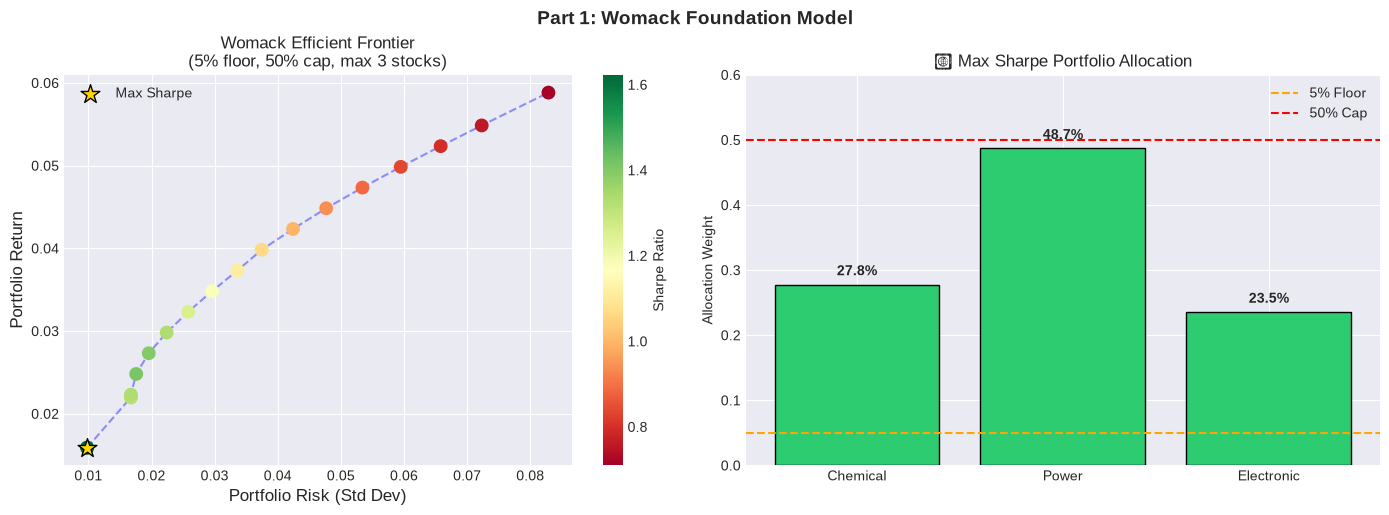

💾 Saved: womack_frontier.png


In [5]:
# ─────────────────────────────────────────────
# PLOT 1: Efficient Frontier (Womack)
# ─────────────────────────────────────────────
risks    = [r['risk'] for r in frontier_results]
rets     = [r['return'] for r in frontier_results]
sharpes  = [r['sharpe'] for r in frontier_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Efficient Frontier
sc = axes[0].scatter(risks, rets, c=sharpes, cmap='RdYlGn', s=80, zorder=5)
axes[0].plot(risks, rets, 'b--', alpha=0.4, lw=1.5)
axes[0].scatter([best['risk']], [best['return']], s=200, marker='*',
                color='gold', edgecolors='black', zorder=10, label='Max Sharpe')
plt.colorbar(sc, ax=axes[0], label='Sharpe Ratio')
axes[0].set_xlabel('Portfolio Risk (Std Dev)', fontsize=12)
axes[0].set_ylabel('Portfolio Return', fontsize=12)
axes[0].set_title(f'Womack Efficient Frontier\n({MIN_ALLOC:.0%} floor, {MAX_ALLOC:.0%} cap, max 3 stocks)', fontsize=12)
axes[0].legend()

# Right: Allocation bar at max Sharpe
alloc_data = {k: v for k, v in best['allocations'].items() if v > 0.001}
colors = ['#2ecc71' if v >= MIN_ALLOC else '#e74c3c' for v in alloc_data.values()]
bars = axes[1].bar(alloc_data.keys(), alloc_data.values(), color=colors, edgecolor='black')
axes[1].axhline(MIN_ALLOC, color='orange', ls='--', label=f'{MIN_ALLOC:.0%} Floor')
axes[1].axhline(MAX_ALLOC, color='red', ls='--', label=f'{MAX_ALLOC:.0%} Cap')
axes[1].set_ylabel('Allocation Weight')
axes[1].set_title('🏆 Max Sharpe Portfolio Allocation', fontsize=12)
axes[1].set_ylim(0, 0.6)
axes[1].legend()
for bar, val in zip(bars, alloc_data.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.suptitle('Part 1: Womack Foundation Model', fontsize=14, fontweight='bold', y=1.02)
plt.savefig('womack_frontier.png', dpi=120, bbox_inches='tight')
plt.show()
print('💾 Saved: womack_frontier.png')


# 📡 Part 2: Real S&P 500 Data Pipeline

Now we graduate from Womack's 5 textbook stocks to **real Yahoo Finance data**.

### The Funnel:
```
S&P 500 (~500 stocks)
       ↓  Filter: 5 sectors, liquidity, data completeness
  Top 100 candidates
       ↓  Rank by: Sharpe ratio over lookback window
    Best 20 per sector (4 stocks × 5 sectors)
       ↓  Optimizer picks best 10
   Final 10-stock portfolio
```

### The 5 Sectors:
| Sector | Examples | Why? |
|--------|----------|------|
| **Technology** | AAPL, MSFT, NVDA | Growth engine |
| **Energy** | XOM, CVX, SLB | Inflation hedge |
| **Healthcare** | JNJ, UNH, PFE | Defensive play |
| **Financials** | JPM, GS, BAC | Interest rate play |
| **Consumer Staples** | PG, KO, WMT | Stability anchor |

In [6]:
# ─────────────────────────────────────────────
# DEFINE THE UNIVERSE: 100 S&P 500 STOCKS
# Curated from top performers in 5 sectors
# ─────────────────────────────────────────────

UNIVERSE = {
    'Technology': [
        'AAPL', 'MSFT', 'NVDA', 'GOOGL', 'META',
        'AVGO', 'AMD', 'ORCL', 'ADBE', 'CRM',
        'INTC', 'QCOM', 'TXN', 'MU', 'AMAT',
        'KLAC', 'LRCX', 'SNPS', 'CDNS', 'MRVL'
    ],
    'Energy': [
        'XOM', 'CVX', 'COP', 'EOG', 'SLB',
        'MPC', 'PSX', 'VLO', 'OXY', 'PXD',
        'HAL', 'DVN', 'FANG', 'HES', 'BKR',
        'APA', 'MRO', 'TRGP', 'WMB', 'KMI'
    ],
    'Healthcare': [
        'UNH', 'JNJ', 'LLY', 'ABBV', 'MRK',
        'TMO', 'ABT', 'DHR', 'PFE', 'AMGN',
        'ISRG', 'SYK', 'BSX', 'MDT', 'EW',
        'HCA', 'CI', 'CVS', 'ANTM', 'HUM'
    ],
    'Financials': [
        'JPM', 'BAC', 'WFC', 'GS', 'MS',
        'BLK', 'SCHW', 'AXP', 'PGR', 'TRV',
        'CB', 'AON', 'MMC', 'ICE', 'CME',
        'SPGI', 'MCO', 'USB', 'PNC', 'TFC'
    ],
    'ConsumerStaples': [
        'PG', 'KO', 'PEP', 'WMT', 'COST',
        'PM', 'MO', 'CL', 'GIS', 'K',
        'HSY', 'MKC', 'SJM', 'CAG', 'CPB',
        'HRL', 'CHD', 'CLX', 'COTY', 'EL'
    ]
}

ALL_TICKERS = [t for sector in UNIVERSE.values() for t in sector]
TICKER_TO_SECTOR = {t: s for s, tickers in UNIVERSE.items() for t in tickers}

print(f'Total Universe: {len(ALL_TICKERS)} stocks across {len(UNIVERSE)} sectors')
for sector, tickers in UNIVERSE.items():
    print(f'  {sector:20s}: {len(tickers)} stocks')

Total Universe: 100 stocks across 5 sectors
  Technology          : 20 stocks
  Energy              : 20 stocks
  Healthcare          : 20 stocks
  Financials          : 20 stocks
  ConsumerStaples     : 20 stocks


In [7]:
# ---------------------------------------------
# DOWNLOAD PRICE DATA FROM YAHOO FINANCE
# Uses 2 years of daily data. yfinance's end date is exclusive, so use tomorrow
# to include the most recent available trading day whenever this notebook runs.
# ---------------------------------------------

DATA_END_DATE = (datetime.today() + timedelta(days=1)).strftime('%Y-%m-%d')
START_DATE = (datetime.today() - timedelta(days=730)).strftime('%Y-%m-%d')

print(f'Downloading data from {START_DATE} to {DATA_END_DATE}...')
print('This may take 30-60 seconds...')

t0 = time.time()

raw_prices = yf.download(
    ALL_TICKERS,
    start=START_DATE,
    end=DATA_END_DATE,
    auto_adjust=True,
    progress=False
)['Close']

if raw_prices.empty:
    raise ValueError('Yahoo Finance returned no price data. Re-run when the data connection is available.')

# Remove tickers with too many NaNs (>10% missing)
threshold = len(raw_prices) * 0.90
prices = raw_prices.dropna(axis=1, thresh=int(threshold))
prices = prices.ffill().dropna()

if prices.empty:
    raise ValueError('All downloaded tickers were filtered out. Check ticker availability or missing data.')

elapsed = time.time() - t0
print(f'\nDownload complete in {elapsed:.1f}s')
print(f'   Stocks with sufficient data: {prices.shape[1]}/{len(ALL_TICKERS)}')
print(f'   Trading days available: {prices.shape[0]}')
print(f'   Date range: {prices.index[0].date()} to {prices.index[-1].date()}')


This may take 30-60 seconds...


$MRO: possibly delisted; no timezone found


$ANTM: possibly delisted; no timezone found


$K: possibly delisted; no timezone found


$MMC: possibly delisted; no timezone found


$HES: possibly delisted; no timezone found


$PXD: possibly delisted; no timezone found



6 Failed downloads:


['MRO', 'ANTM', 'K', 'MMC', 'HES', 'PXD']: possibly delisted; no timezone found



Download complete in 16.4s
   Stocks with sufficient data: 94/100
   Trading days available: 502
   Date range: 2024-07-16 to 2026-07-16


In [8]:
# ─────────────────────────────────────────────
# FILTER TO TOP 100 STOCKS
# Ranking Criterion: Sharpe ratio over full window
# Additional filters: must be in universe AND
#                     have data, cap at 20/sector
# ─────────────────────────────────────────────

# Daily returns
daily_returns = prices.pct_change().dropna()

# Compute per-stock statistics
stock_stats = pd.DataFrame({
    'mean_return':  daily_returns.mean(),
    'std_return':   daily_returns.std(),
    'sharpe':       daily_returns.mean() / daily_returns.std(),
    'total_return': (prices.iloc[-1] / prices.iloc[0] - 1),
    'sector':       pd.Series({t: TICKER_TO_SECTOR.get(t, 'Unknown') for t in daily_returns.columns})
})

# Filter to tickers in our universe
stock_stats = stock_stats[stock_stats['sector'] != 'Unknown']

# Select top 4 by Sharpe per sector (= 20 stocks, 4 × 5 sectors)
TOP_N_PER_SECTOR = 4
top_by_sector = (
    stock_stats
    .sort_values('sharpe', ascending=False)
    .groupby('sector')
    .head(TOP_N_PER_SECTOR)
)

TOP20_TICKERS = top_by_sector.index.tolist()
print(f'Selected {len(TOP20_TICKERS)} stocks (top {TOP_N_PER_SECTOR} per sector)')
print()
print(top_by_sector[['sector','mean_return','std_return','sharpe','total_return']]
      .round(4)
      .sort_values(['sector','sharpe'], ascending=[True, False])
      .to_string())

Selected 20 stocks (top 4 per sector)

                sector  mean_return  std_return  sharpe  total_return
MO     ConsumerStaples       0.0012      0.0136  0.0887        0.7479
PM     ConsumerStaples       0.0015      0.0172  0.0848        0.9268
WMT    ConsumerStaples       0.0011      0.0153  0.0748        0.6731
KO     ConsumerStaples       0.0007      0.0109  0.0666        0.3985
WMB             Energy       0.0014      0.0158  0.0881        0.8883
TRGP            Energy       0.0018      0.0202  0.0867        1.1680
KMI             Energy       0.0012      0.0147  0.0836        0.7538
VLO             Energy       0.0018      0.0234  0.0765        1.1338
GS          Financials       0.0018      0.0205  0.0901        1.2682
MS          Financials       0.0017      0.0195  0.0892        1.1727
TRV         Financials       0.0010      0.0143  0.0730        0.6024
JPM         Financials       0.0012      0.0160  0.0722        0.6739
JNJ         Healthcare       0.0012      0.0120  0.

# Part 3: Model 1 - Full Integer Portfolio Optimizer

### What's new vs Womack?

| Feature | Womack | Model 1 (This) |
|---------|--------|----------------|
| Stocks | 5 (textbook) | 20 real S&P 500 |
| Pick exactly | 3 | **10** |
| Sectors | 5 (textbook) | **5 real sectors** |
| Min allocation | None | **5% per selected stock** |
| Max allocation | None | **50% per selected stock** |
| Sector diversification | None | **Exactly 2 stocks from each of 5 sectors** |
| Objective | Minimize variance | **Automatically select max-Sharpe point from the efficient frontier** |

### The Math:
$$\max \frac{\sum_k \mu_k X_k - r_f}{\sqrt{\sum_i \sum_j \sigma_{ij} X_i X_j}}$$

Solved by tracing target-return points on the efficient frontier and choosing the highest Sharpe ratio.

Subject to:
- $\sum_k X_k = 1$ (budget)
- $0.05 \cdot Y_k \leq X_k \leq 0.50 \cdot Y_k$ (linking constraints)
- $\sum_k Y_k = 10$ (exactly 10 stocks)
- $\sum_{k \in \text{sector}_s} Y_k = 2 \quad \forall s$ (balanced sector diversity)
- $Y_k \in \{0, 1\}$, $X_k \geq 0$


In [9]:
# ---------------------------------------------
# MODEL 1: FULL INTEGER PORTFOLIO OPTIMIZER
# Automatically picks the max-Sharpe point from the efficient frontier.
# ---------------------------------------------

def _available_bonmin_solver():
    bonmin_path = shutil.which('bonmin')
    if not bonmin_path:
        return None
    solver = SolverFactory('bonmin', executable=bonmin_path)
    return solver if solver.available(exception_flag=False) else None


def has_required_sector_balance(tickers, ticker_sector_map, min_per_sector=MIN_PER_SECTOR):
    """True when the candidate set can supply the required number from every sector."""
    counts = pd.Series([ticker_sector_map.get(t, 'Unknown') for t in tickers]).value_counts()
    return all(counts.get(sec, 0) >= min_per_sector for sec in UNIVERSE.keys())


def _heuristic_seed_selection(tickers, mu, cov, sectors, n_select, min_per_sector):
    """Fallback selector used only when Bonmin is unavailable."""
    vol = np.sqrt(np.maximum(np.diag(cov), 1e-12))
    score = (mu - RISK_FREE_DAILY) / vol
    df = pd.DataFrame({'ticker': tickers, 'mu': mu, 'score': score, 'sector': sectors})

    selected = []
    for sec, part in df.sort_values('score', ascending=False).groupby('sector'):
        selected.extend(part.head(min_per_sector)['ticker'].tolist())

    selected = list(dict.fromkeys(selected))
    remaining = df[~df['ticker'].isin(selected)].sort_values('score', ascending=False)
    selected.extend(remaining.head(max(0, n_select - len(selected)))['ticker'].tolist())
    return selected[:n_select]


def _optimize_selected_weights(mu, cov, target_return, min_alloc, max_alloc):
    n = len(mu)
    x0 = np.repeat(1 / n, n)
    bounds = [(min_alloc, max_alloc)] * n
    constraints = [
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'ineq', 'fun': lambda x: np.dot(mu, x) - target_return},
    ]

    res = scipy_minimize(
        lambda x: float(x @ cov @ x),
        x0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 500, 'ftol': 1e-10}
    )

    if res.success and np.isfinite(res.fun):
        return res.x

    # Last-resort feasible allocation.  This still respects budget and min/max.
    if min_alloc * n <= 1 <= max_alloc * n:
        return x0
    return None


def solve_real_portfolio(
    returns_df,
    ticker_sector_map,
    n_select=N_SELECT,
    min_alloc=MIN_ALLOC,
    max_alloc=MAX_ALLOC,
    min_per_sector=MIN_PER_SECTOR,
    risk_free_rate=RISK_FREE_DAILY,
    risk_target=None,
    return_estimates=None
):
    """
    Solve one efficient-frontier target-return point.

    Uses binary Y variables and continuous X variables with linking constraints:
        min_alloc * Y[k] <= X[k] <= max_alloc * Y[k]

    If Bonmin is unavailable, falls back to a deterministic constrained
    selection + SLSQP weight optimizer so the notebook remains runnable.
    """
    returns_df = returns_df.dropna(axis=1, how='any')
    tickers = list(returns_df.columns)
    n = len(tickers)

    if n < n_select:
        return {'status': 'infeasible', 'return': 0, 'risk': 0, 'sharpe': -np.inf,
                'allocations': {}, 'selected': {}, 'solver': 'none'}

    if min_alloc * n_select > 1 + 1e-9 or max_alloc * n_select < 1 - 1e-9:
        raise ValueError('Allocation floor/cap are infeasible for the required number of selected stocks.')

    hist_mu = returns_df.mean()
    mu_series = pd.Series(return_estimates, index=tickers).reindex(tickers).astype(float) if return_estimates is not None else hist_mu
    mu = mu_series.values
    cov = returns_df.cov().values
    sectors = [ticker_sector_map.get(t, 'Unknown') for t in tickers]
    unique_sectors = sorted(set(sectors))

    if risk_target is None:
        risk_target = float(np.nanmean(mu))

    solver = _available_bonmin_solver()
    if solver is not None:
        model = ConcreteModel()
        model.K = RangeSet(0, n - 1)
        model.X = Var(model.K, domain=NonNegativeReals, bounds=(0, 1))
        model.Y = Var(model.K, domain=Binary)

        model.obj = Objective(
            expr=sum(cov[i][j] * model.X[i] * model.X[j]
                     for i in range(n) for j in range(n)),
            sense=minimize
        )
        model.budget = Constraint(expr=sum(model.X[k] for k in model.K) == 1)
        model.ret_con = Constraint(expr=sum(mu[k] * model.X[k] for k in model.K) >= risk_target)

        model.floor_con = ConstraintList()
        model.cap_con = ConstraintList()
        for k in range(n):
            model.floor_con.add(model.X[k] >= min_alloc * model.Y[k])
            model.cap_con.add(model.X[k] <= max_alloc * model.Y[k])

        model.count = Constraint(expr=sum(model.Y[k] for k in model.K) == n_select)

        model.sector_con = ConstraintList()
        for sec in unique_sectors:
            sec_idx = [k for k, s in enumerate(sectors) if s == sec]
            if sec_idx:
                model.sector_con.add(sum(model.Y[k] for k in sec_idx) == min_per_sector)

        try:
            result = solver.solve(model, tee=False)
            if result.solver.termination_condition in [TerminationCondition.optimal, TerminationCondition.feasible]:
                weights = np.array([max(0, value(model.X[k])) for k in range(n)])
                if weights.sum() > 0:
                    weights = weights / weights.sum()
                allocs = {tickers[k]: float(weights[k]) for k in range(n)}
                selected = {tickers[k]: int(round(value(model.Y[k]))) for k in range(n)}
                port_var = float(weights @ cov @ weights)
                port_ret = float(mu @ weights)
                port_risk = max(port_var, 0) ** 0.5
                sharpe = (port_ret - risk_free_rate) / port_risk if port_risk > 1e-10 else -np.inf
                return {
                    'allocations': allocs, 'selected': selected,
                    'return': port_ret, 'risk': port_risk, 'variance': port_var,
                    'sharpe': sharpe, 'status': 'optimal', 'solver': 'bonmin'
                }
        except Exception as exc:
            print(f'Bonmin failed on this target; using fallback. Details: {str(exc)[:120]}')

    selected_tickers = _heuristic_seed_selection(tickers, mu, cov, sectors, n_select, min_per_sector)
    idx = [tickers.index(t) for t in selected_tickers]
    weights_sel = _optimize_selected_weights(mu[idx], cov[np.ix_(idx, idx)], risk_target, min_alloc, max_alloc)
    if weights_sel is None:
        return {'status': 'infeasible', 'return': 0, 'risk': 0, 'sharpe': -np.inf,
                'allocations': {}, 'selected': {}, 'solver': 'fallback'}

    weights = np.zeros(n)
    weights[idx] = weights_sel
    allocs = {tickers[k]: float(weights[k]) for k in range(n)}
    selected = {tickers[k]: int(weights[k] > 1e-8) for k in range(n)}
    port_var = float(weights @ cov @ weights)
    port_ret = float(mu @ weights)
    port_risk = max(port_var, 0) ** 0.5
    sharpe = (port_ret - risk_free_rate) / port_risk if port_risk > 1e-10 else -np.inf
    return {
        'allocations': allocs, 'selected': selected,
        'return': port_ret, 'risk': port_risk, 'variance': port_var,
        'sharpe': sharpe, 'status': 'optimal', 'solver': 'scipy_fallback'
    }


def solve_max_sharpe_portfolio(
    returns_df,
    ticker_sector_map,
    n_select=N_SELECT,
    min_alloc=MIN_ALLOC,
    max_alloc=MAX_ALLOC,
    min_per_sector=MIN_PER_SECTOR,
    return_estimates=None,
    n_targets=12
):
    """Trace target-return points and choose the highest Sharpe automatically."""
    returns_df = returns_df.dropna(axis=1, how='any')
    tickers = list(returns_df.columns)
    mu_series = pd.Series(return_estimates, index=tickers).reindex(tickers).astype(float) if return_estimates is not None else returns_df.mean()
    mu = mu_series.values

    lo = float(np.nanpercentile(mu, 20))
    hi = float(np.nanpercentile(mu, 90))
    if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
        lo, hi = float(np.nanmin(mu)), float(np.nanmax(mu))
    target_grid = np.linspace(lo, hi, n_targets)

    candidates = []
    for target in target_grid:
        res = solve_real_portfolio(
            returns_df,
            ticker_sector_map,
            n_select=n_select,
            min_alloc=min_alloc,
            max_alloc=max_alloc,
            min_per_sector=min_per_sector,
            risk_target=target,
            return_estimates=mu_series
        )
        if res['status'] == 'optimal' and np.isfinite(res['sharpe']):
            res['target_return'] = target
            candidates.append(res)

    if not candidates:
        return {'status': 'infeasible', 'allocations': {}, 'selected': {}, 'sharpe': -np.inf}

    return max(candidates, key=lambda r: r['sharpe'])


# ---------------------------------------------
# RUN: Trace frontier for the top-20 real stocks
# ---------------------------------------------
top20_returns = daily_returns[TOP20_TICKERS].copy()
top20_sectors = {t: TICKER_TO_SECTOR[t] for t in TOP20_TICKERS}

mu_top20 = top20_returns.mean().values
target_range = np.linspace(np.nanpercentile(mu_top20, 20), np.nanpercentile(mu_top20, 90), 15)

print('Tracing Model 1 Efficient Frontier (Real S&P 500 stocks)...')
print('Each point is a constrained integer allocation solve.')

model1_frontier = []
t0 = time.time()
for i, rt in enumerate(target_range):
    res = solve_real_portfolio(
        top20_returns,
        top20_sectors,
        n_select=N_SELECT,
        min_alloc=MIN_ALLOC,
        max_alloc=MAX_ALLOC,
        min_per_sector=MIN_PER_SECTOR,
        risk_target=rt
    )
    if res['status'] == 'optimal':
        model1_frontier.append(res)
    if (i + 1) % 5 == 0:
        print(f'  [{i + 1}/{len(target_range)}] solved...')

elapsed = time.time() - t0
print(f'\nFrontier traced: {len(model1_frontier)} feasible points in {elapsed:.1f}s')

if not model1_frontier:
    raise RuntimeError('No feasible Model 1 frontier points were found. Check solver/data availability.')

best_m1 = max(model1_frontier, key=lambda r: r['sharpe'])
chosen_tickers_m1 = [t for t, y in best_m1['selected'].items() if y > 0.5]

print(f'\nModel 1 Max Sharpe Portfolio:')
print(f'   Return: {best_m1["return"] * 252:.2%} annualized')
print(f'   Risk:   {best_m1["risk"] * np.sqrt(252):.2%} annualized')
print(f'   Sharpe: {best_m1["sharpe"] * np.sqrt(252):.3f} annualized')
print(f'   Solver: {best_m1.get("solver", "unknown")}')
print()
for t in chosen_tickers_m1:
    alloc = best_m1['allocations'][t]
    sector = top20_sectors[t]
    print(f'   {t:6s} ({sector:18s}): {alloc:.1%}')


Tracing Model 1 Efficient Frontier (Real S&P 500 stocks)...
Each point is a constrained integer allocation solve.


  [5/15] solved...


  [10/15] solved...


  [15/15] solved...

Frontier traced: 15 feasible points in 0.5s

Model 1 Max Sharpe Portfolio:
   Return: 43.28% annualized
   Risk:   14.16% annualized
   Sharpe: 2.878 annualized
   Solver: scipy_fallback

   MU     (Technology        ): 8.3%
   JNJ    (Healthcare        ): 30.3%
   GS     (Financials        ): 5.0%
   MS     (Financials        ): 5.0%
   MO     (ConsumerStaples   ): 22.1%
   WMB    (Energy            ): 5.0%
   TRGP   (Energy            ): 5.0%
   PM     (ConsumerStaples   ): 8.7%
   LRCX   (Technology        ): 5.0%
   CVS    (Healthcare        ): 5.6%


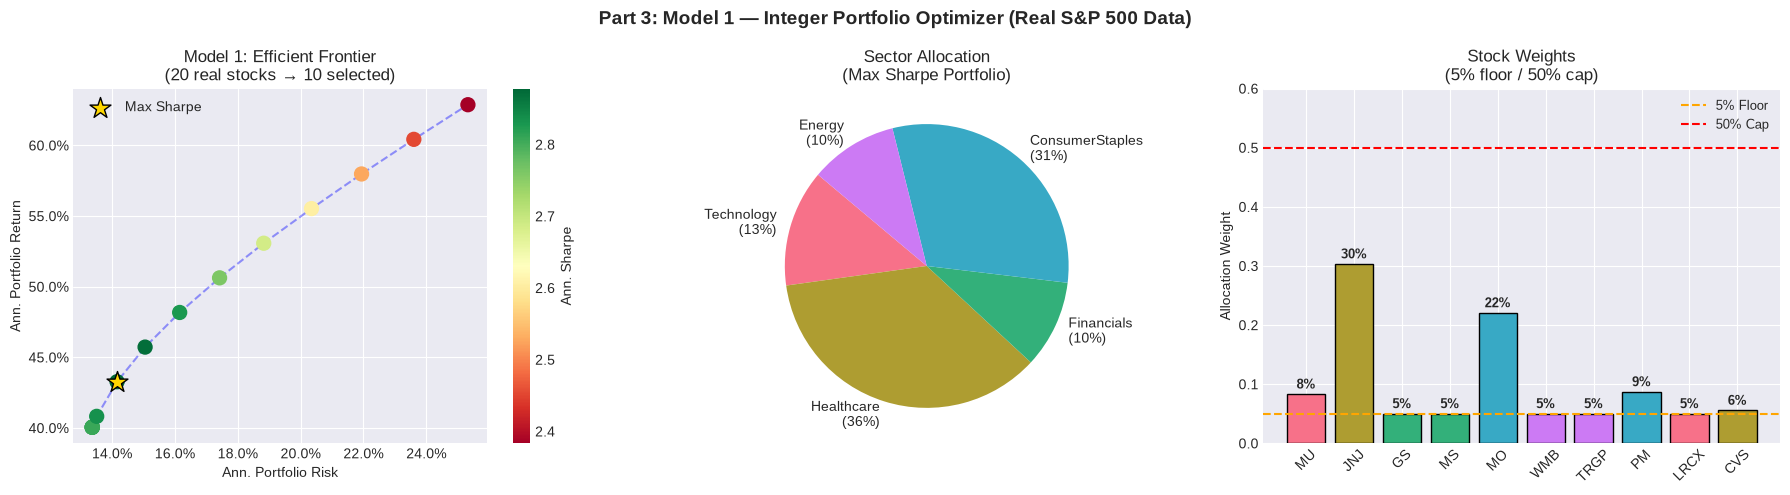

In [10]:
# ─────────────────────────────────────────────
# PLOT 2: Model 1 Results
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel 1: Efficient Frontier ---
risks1  = [r['risk']*np.sqrt(252) for r in model1_frontier]
rets1   = [r['return']*252 for r in model1_frontier]
sharpes1= [r['sharpe']*np.sqrt(252) for r in model1_frontier]

sc = axes[0].scatter(risks1, rets1, c=sharpes1, cmap='RdYlGn', s=100, zorder=5)
axes[0].plot(risks1, rets1, 'b--', alpha=0.4)
axes[0].scatter(
    [best_m1['risk']*np.sqrt(252)], [best_m1['return']*252],
    s=250, marker='*', color='gold', edgecolors='black', zorder=10, label='Max Sharpe'
)
plt.colorbar(sc, ax=axes[0], label='Ann. Sharpe')
axes[0].set_xlabel('Ann. Portfolio Risk')
axes[0].set_ylabel('Ann. Portfolio Return')
axes[0].set_title('Model 1: Efficient Frontier\n(20 real stocks → 10 selected)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))

# --- Panel 2: Sector Allocation Pie ---
sector_allocs = {}
for t in chosen_tickers_m1:
    sec = top20_sectors[t]
    sector_allocs[sec] = sector_allocs.get(sec, 0) + best_m1['allocations'][t]
axes[1].pie(
    sector_allocs.values(),
    labels=[f'{s}\n({v:.0%})' for s, v in sector_allocs.items()],
    autopct='',
    colors=sns.color_palette('husl', len(sector_allocs)),
    startangle=140, pctdistance=0.8
)
axes[1].set_title('Sector Allocation\n(Max Sharpe Portfolio)')

# --- Panel 3: Stock Weights Bar ---
alloc_vals = {t: best_m1['allocations'][t] for t in chosen_tickers_m1}
colors3 = [sns.color_palette('husl', len(sector_allocs))[list(sector_allocs.keys()).index(top20_sectors[t])]
           for t in chosen_tickers_m1]
bars3 = axes[2].bar(alloc_vals.keys(), alloc_vals.values(), color=colors3, edgecolor='black')
axes[2].axhline(MIN_ALLOC, color='orange', ls='--', lw=1.5, label=f'{MIN_ALLOC:.0%} Floor')
axes[2].axhline(MAX_ALLOC, color='red', ls='--', lw=1.5, label=f'{MAX_ALLOC:.0%} Cap')
for bar, val in zip(bars3, alloc_vals.values()):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.0%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[2].set_ylabel('Allocation Weight')
axes[2].set_title(f'Stock Weights\n({MIN_ALLOC:.0%} floor / {MAX_ALLOC:.0%} cap)')
axes[2].set_ylim(0, max(0.60, MAX_ALLOC + 0.10))
axes[2].legend(fontsize=9)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Part 3: Model 1 — Integer Portfolio Optimizer (Real S&P 500 Data)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model1_results.png', dpi=120, bbox_inches='tight')
plt.show()


# 📉 Part 4: Moving Average Signal Filters

This is where we add **market intelligence** on top of pure optimization.

### The Idea:
Before the optimizer even *considers* a stock, it must pass a **momentum screen**. The logic:

- Compute 5-day, 10-day, and 15-day moving averages for each stock
- A stock gets a **green light** if its current price is ABOVE its 15-day MA
- A stock gets a **stronger signal** if MA5 > MA10 > MA15 (classic uptrend alignment)
- Stocks in downtrends are **excluded** from the optimizer's candidate pool

### Why This Works:
> *"The trend is your friend." — Every trading floor ever*

Momentum is one of the most robust anomalies in finance. Stocks that have been going up tend to continue going up over the next few days. By filtering to only uptrending stocks, we avoid buying into falling knives.

### The MA Score:
$$\text{MA\_Score}(k) = \mathbb{1}[P_k > MA_{15,k}] + \mathbb{1}[MA_{5,k} > MA_{10,k}] + \mathbb{1}[MA_{10,k} > MA_{15,k}]$$

Score = 3: **Strong uptrend** | Score = 2: **Moderate trend** | Score ≤ 1: **Excluded**

In [11]:
# ─────────────────────────────────────────────
# COMPUTE MOVING AVERAGES FOR ALL TOP-20 STOCKS
# ─────────────────────────────────────────────

top20_prices = prices[TOP20_TICKERS].copy()

ma_signals = {}

for ticker in TOP20_TICKERS:
    price_series = top20_prices[ticker]
    current_price = price_series.iloc[-1]

    ma5  = price_series.rolling(5).mean().iloc[-1]
    ma10 = price_series.rolling(10).mean().iloc[-1]
    ma15 = price_series.rolling(15).mean().iloc[-1]

    # Signal scoring
    above_ma15  = int(current_price > ma15)
    ma5_gt_ma10 = int(ma5 > ma10)
    ma10_gt_ma15= int(ma10 > ma15)

    score = above_ma15 + ma5_gt_ma10 + ma10_gt_ma15

    ma_signals[ticker] = {
        'current_price': current_price,
        'ma5':  ma5,
        'ma10': ma10,
        'ma15': ma15,
        'above_ma15':   above_ma15,
        'ma5_gt_ma10':  ma5_gt_ma10,
        'ma10_gt_ma15': ma10_gt_ma15,
        'ma_score':     score,
        'trend':        'STRONG UP' if score == 3 else
                        'MOD UP'    if score == 2 else
                        'NEUTRAL'   if score == 1 else 'DOWN',
        'eligible':     score >= 2   # require at least 2 of 3 signals
    }

ma_df = pd.DataFrame(ma_signals).T
ma_df['sector'] = ma_df.index.map(top20_sectors)
ma_df['ma_score'] = ma_df['ma_score'].astype(int)

eligible_tickers = [t for t in TOP20_TICKERS if ma_signals[t]['eligible']]

print('Moving Average Signal Report (Most Recent Trading Day)')
print('='*70)
print(ma_df[['sector','current_price','ma5','ma10','ma15','ma_score','trend','eligible']]
      .sort_values('ma_score', ascending=False)
      .to_string())
print()
print(f'Eligible stocks (score >= 2): {len(eligible_tickers)}/{len(TOP20_TICKERS)}')
print(f'Eligible: {eligible_tickers}')

Moving Average Signal Report (Most Recent Trading Day)
                sector current_price          ma5        ma10         ma15  ma_score      trend eligible
GS          Financials   1095.459961  1097.723999     1069.35  1055.292664         3  STRONG UP     True
CVS         Healthcare         106.5   105.728001  104.705001      104.526         3  STRONG UP     True
VLO             Energy     300.26001   294.166003  283.926004   276.659336         3  STRONG UP     True
TRGP            Energy    280.269989      278.556  273.986996   272.215332         3  STRONG UP     True
KO     ConsumerStaples     84.919998    83.637999      83.537    82.908666         3  STRONG UP     True
JPM         Financials    343.149994   340.790002  337.995001   335.165863         3  STRONG UP     True
MS          Financials    218.369995   223.591998     221.623   218.794666         2     MOD UP     True
TRV         Financials    337.820007   336.854004  338.490005   335.145337         2     MOD UP     True


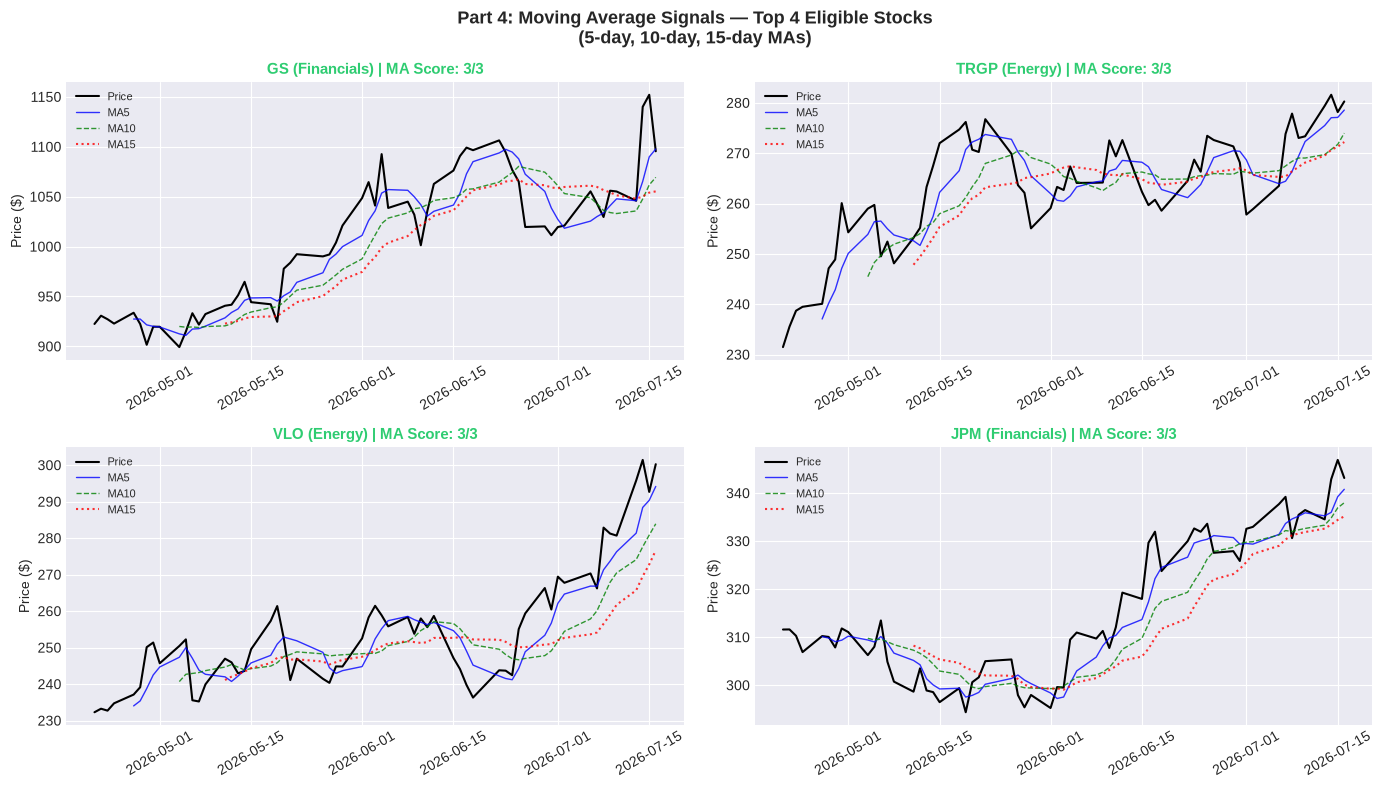

In [12]:
# ─────────────────────────────────────────────
# PLOT 3: MA Signal Dashboard
# ─────────────────────────────────────────────

# Show price + MAs for top 4 eligible stocks
display_stocks = sorted(eligible_tickers, key=lambda t: ma_signals[t]['ma_score'], reverse=True)[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, ticker in enumerate(display_stocks):
    ax = axes[i]
    price_series = top20_prices[ticker].iloc[-60:]  # last 60 trading days
    ma5_series   = price_series.rolling(5).mean()
    ma10_series  = price_series.rolling(10).mean()
    ma15_series  = price_series.rolling(15).mean()

    ax.plot(price_series.index, price_series.values, 'k-', lw=1.5, label='Price')
    ax.plot(ma5_series.index,  ma5_series.values,  'b-',  lw=1, label='MA5',  alpha=0.8)
    ax.plot(ma10_series.index, ma10_series.values, 'g--', lw=1, label='MA10', alpha=0.8)
    ax.plot(ma15_series.index, ma15_series.values, 'r:',  lw=1.5, label='MA15', alpha=0.8)

    score = ma_signals[ticker]['ma_score']
    color = '#2ecc71' if score == 3 else '#f39c12' if score == 2 else '#e74c3c'
    sector = top20_sectors[ticker]
    ax.set_title(f'{ticker} ({sector}) | MA Score: {score}/3',
                 fontsize=11, color=color, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_ylabel('Price ($)')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Part 4: Moving Average Signals — Top 4 Eligible Stocks\n(5-day, 10-day, 15-day MAs)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ma_signals.png', dpi=120, bbox_inches='tight')
plt.show()

# 🤖 Part 5: Model 2 — XGBoost Return Predictor + Constrained Allocation

### Why XGBoost?

XGBoost (eXtreme Gradient Boosting) is a **gradient-boosted decision tree** ensemble. It's the algorithm that has won more Kaggle competitions than any other, and it's a staple of quant research desks at hedge funds for good reason:

1. **Handles non-linear relationships** between technical features and returns
2. **Robust to outliers** — doesn't blow up on volatile days
3. **Feature importance** — tells you WHICH signals matter
4. **Fast** — trains in seconds even on large datasets

### The Pipeline:

```
For each stock:
  Features: [MA5, MA10, MA15, RSI14, MACD, Volatility, Lag1Return, Lag2Return, Lag5Return]
  Target: Next-day return
  
  Train XGBoost → predict tomorrow's return

Use XGBoost predictions as EXPECTED RETURNS in Pyomo model
(instead of historical mean returns)
```

### Why Better Than Historical Mean?
> Historical mean returns assume *"the future will look like the average of the past."* XGBoost says *"given TODAY's specific market conditions (momentum, RSI, volatility), what does the future likely look like?"* That's a smarter starting point for the optimizer.

In [13]:
# ─────────────────────────────────────────────
# FEATURE ENGINEERING FOR XGBOOST
# ─────────────────────────────────────────────

def compute_rsi(prices, period=14):
    """Relative Strength Index"""
    delta = prices.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

def compute_macd(prices, fast=12, slow=26, signal=9):
    """MACD Line"""
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    return macd_line

def build_features(prices_series, returns_series):
    """
    Build ML feature matrix for a single stock.
    Features: technical indicators + lagged returns
    Target: next-day return
    """
    df = pd.DataFrame(index=prices_series.index)

    # Price-based MAs (normalized as ratio to current price)
    df['ma5_ratio']  = prices_series.rolling(5).mean()  / prices_series
    df['ma10_ratio'] = prices_series.rolling(10).mean() / prices_series
    df['ma15_ratio'] = prices_series.rolling(15).mean() / prices_series
    df['ma20_ratio'] = prices_series.rolling(20).mean() / prices_series

    # Momentum indicators
    df['rsi14']  = compute_rsi(prices_series, 14)
    df['macd']   = compute_macd(prices_series)

    # Volatility
    df['vol5']   = returns_series.rolling(5).std()
    df['vol10']  = returns_series.rolling(10).std()
    df['vol20']  = returns_series.rolling(20).std()

    # Lagged returns
    for lag in [1, 2, 3, 5]:
        df[f'ret_lag{lag}'] = returns_series.shift(lag)

    # Rolling mean return
    df['mean_ret5']  = returns_series.rolling(5).mean()
    df['mean_ret10'] = returns_series.rolling(10).mean()

    # Target: next-day return
    df['target'] = returns_series.shift(-1)

    return df.dropna()


print('Feature set for XGBoost:')
sample = build_features(top20_prices[TOP20_TICKERS[0]],
                        daily_returns[TOP20_TICKERS[0]])
feature_cols = [c for c in sample.columns if c != 'target']
print(f'  {len(feature_cols)} features: {feature_cols}')
print(f'  Training samples per stock: {len(sample)}')

Feature set for XGBoost:
  15 features: ['ma5_ratio', 'ma10_ratio', 'ma15_ratio', 'ma20_ratio', 'rsi14', 'macd', 'vol5', 'vol10', 'vol20', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'mean_ret5', 'mean_ret10']
  Training samples per stock: 481


In [14]:
# ─────────────────────────────────────────────
# TRAIN XGBOOST FOR EACH TOP-20 STOCK
# Walk-forward validation: last 20% = test
# ─────────────────────────────────────────────

xgb_models     = {}
xgb_predictions= {}  # predicted next-day return
xgb_scores     = {}  # test RMSE
xgb_importances= {}
scalers        = {}

print('Training XGBoost models...')
t0 = time.time()

for ticker in TOP20_TICKERS:
    feat_df = build_features(top20_prices[ticker], daily_returns[ticker])

    X = feat_df[feature_cols].values
    y = feat_df['target'].values

    # Walk-forward split: last 20% as test
    split = int(len(X) * 0.80)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Scale features
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # XGBoost model
    xgb = XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
        n_jobs=-1
    )
    xgb.fit(X_train_sc, y_train,
            eval_set=[(X_test_sc, y_test)],
            verbose=False)

    # Predict next day's return (use last available row)
    last_features = scaler.transform(X[-1:].reshape(1, -1))
    predicted_return = xgb.predict(last_features)[0]

    # Test error
    y_pred_test = xgb.predict(X_test_sc)
    rmse = mean_squared_error(y_test, y_pred_test) ** 0.5

    xgb_models[ticker]      = xgb
    xgb_predictions[ticker] = predicted_return
    xgb_scores[ticker]      = rmse
    scalers[ticker]         = scaler
    xgb_importances[ticker] = dict(zip(feature_cols, xgb.feature_importances_))

elapsed = time.time() - t0
print(f'✅ All XGBoost models trained in {elapsed:.1f}s')
print()
print('XGBoost Predictions for Tomorrow:')
print('-'*50)
pred_df = pd.DataFrame({
    'Sector': {t: TICKER_TO_SECTOR[t] for t in TOP20_TICKERS},
    'XGB_Predicted_Return': xgb_predictions,
    'Historical_Mean': daily_returns[TOP20_TICKERS].mean().to_dict(),
    'Test_RMSE': xgb_scores,
}).sort_values('XGB_Predicted_Return', ascending=False)
print(pred_df.round(5).to_string())

Training XGBoost models...


✅ All XGBoost models trained in 2.6s

XGBoost Predictions for Tomorrow:
--------------------------------------------------
                Sector  XGB_Predicted_Return  Historical_Mean  Test_RMSE
MU          Technology               0.01950          0.00479    0.06550
KLAC        Technology               0.01645          0.00246    0.04819
TRGP            Energy               0.01533          0.00175    0.01780
JNJ         Healthcare               0.01388          0.00119    0.01435
LRCX        Technology               0.00898          0.00284    0.04737
WMB             Energy               0.00800          0.00140    0.01477
GOOGL       Technology               0.00538          0.00152    0.02297
TRV         Financials               0.00505          0.00104    0.01272
KO     ConsumerStaples               0.00336          0.00073    0.01269
HCA         Healthcare               0.00303          0.00057    0.02182
WMT    ConsumerStaples               0.00265          0.00114    0.01843
P

In [15]:
# ---------------------------------------------
# MODEL 2: XGBOOST-INFORMED PORTFOLIO OPTIMIZER
# Uses the same binding constraints as Model 1, with XGBoost expected returns.
# ---------------------------------------------

print('=== MODEL 2: XGBoost + Integer Optimizer ===')
print()

eligible_for_m2 = [
    t for t in TOP20_TICKERS
    if ma_signals[t]['eligible'] and t in daily_returns.columns
]

print(f'After MA filter: {len(eligible_for_m2)} eligible stocks from {len(TOP20_TICKERS)}')

if len(eligible_for_m2) < N_SELECT or not has_required_sector_balance(eligible_for_m2, TICKER_TO_SECTOR):
    print('WARNING: MA filter cannot supply 2 stocks per sector. Relaxing MA threshold to score >= 1')
    eligible_for_m2 = [
        t for t in TOP20_TICKERS
        if ma_signals[t]['ma_score'] >= 1 and t in daily_returns.columns
    ]

if len(eligible_for_m2) < N_SELECT or not has_required_sector_balance(eligible_for_m2, TICKER_TO_SECTOR):
    print('WARNING: Filtered set still cannot supply 2 per sector. Using all top-20 tickers.')
    eligible_for_m2 = [t for t in TOP20_TICKERS if t in daily_returns.columns]

xgb_mu_series = pd.Series(xgb_predictions).reindex(eligible_for_m2).astype(float)
m2_returns_df = daily_returns[eligible_for_m2].copy()
sectors_m2 = {t: TICKER_TO_SECTOR[t] for t in eligible_for_m2}

best_m2 = solve_max_sharpe_portfolio(
    m2_returns_df,
    sectors_m2,
    n_select=N_SELECT,
    min_alloc=MIN_ALLOC,
    max_alloc=MAX_ALLOC,
    min_per_sector=MIN_PER_SECTOR,
    return_estimates=xgb_mu_series,
    n_targets=12
)

if best_m2.get('status') != 'optimal':
    raise RuntimeError('Model 2 could not find a feasible constrained allocation.')

chosen_m2 = [t for t, y in best_m2['selected'].items() if y > 0.5]

print(f'\nModel 2 (XGBoost) Max Sharpe Portfolio:')
print(f'   Predicted Return: {best_m2["return"] * 252:.2%} annualized')
print(f'   Predicted Risk:   {best_m2["risk"] * np.sqrt(252):.2%} annualized')
print(f'   Predicted Sharpe: {best_m2["sharpe"] * np.sqrt(252):.3f} annualized')
print(f'   Solver: {best_m2.get("solver", "unknown")}')
print()
print('Stock     Sector               MA Score  XGB Pred    Weight')
print('-' * 70)
for t in chosen_m2:
    w = best_m2['allocations'][t]
    sec = TICKER_TO_SECTOR[t]
    ma_score = ma_signals[t]['ma_score']
    xgb_pred = xgb_predictions[t]
    print(f'{t:6s}    {sec:20s} {ma_score}/3       {xgb_pred:+.4f}    {w:.1%}')


=== MODEL 2: XGBoost + Integer Optimizer ===

After MA filter: 12 eligible stocks from 20



Model 2 (XGBoost) Max Sharpe Portfolio:
   Predicted Return: 290.64% annualized
   Predicted Risk:   14.17% annualized
   Predicted Sharpe: 20.330 annualized
   Solver: scipy_fallback

Stock     Sector               MA Score  XGB Pred    Weight
----------------------------------------------------------------------
MU        Technology           0/3       +0.0195    6.8%
JNJ       Healthcare           1/3       +0.0139    46.4%
GS        Financials           3/3       +0.0007    5.0%
WMB       Energy               1/3       +0.0080    5.0%
TRGP      Energy               3/3       +0.0153    11.8%
WMT       ConsumerStaples      2/3       +0.0026    5.0%
TRV       Financials           2/3       +0.0051    5.0%
KLAC      Technology           0/3       +0.0165    5.0%
KO        ConsumerStaples      3/3       +0.0034    5.0%
HCA       Healthcare           1/3       +0.0030    5.0%


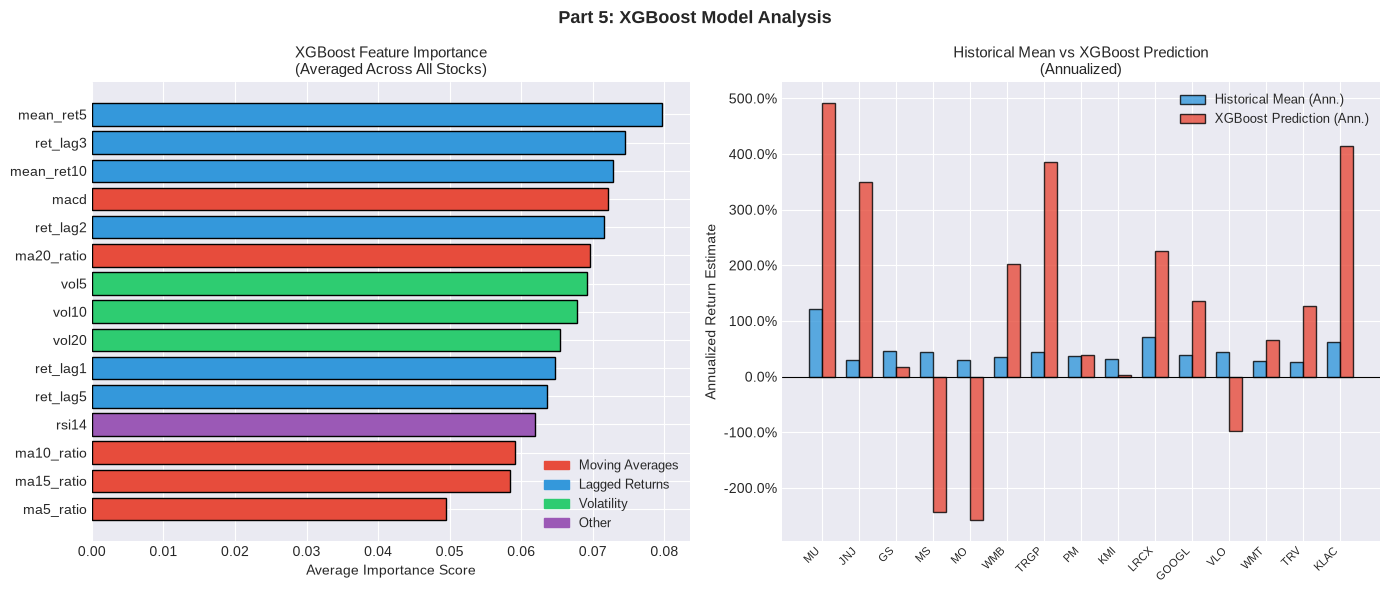

In [16]:
# ─────────────────────────────────────────────
# PLOT 4: XGBoost Feature Importances
# ─────────────────────────────────────────────

# Aggregate feature importance across all stocks
avg_importance = pd.DataFrame(xgb_importances).T.mean()
avg_importance = avg_importance.sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Feature Importance
colors_fi = ['#e74c3c' if 'ma' in c else '#3498db' if 'ret' in c else
             '#2ecc71' if 'vol' in c else '#9b59b6'
             for c in avg_importance.index]
axes[0].barh(avg_importance.index, avg_importance.values, color=colors_fi, edgecolor='black')
axes[0].set_xlabel('Average Importance Score')
axes[0].set_title('XGBoost Feature Importance\n(Averaged Across All Stocks)', fontsize=11)

legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Moving Averages'),
    mpatches.Patch(color='#3498db', label='Lagged Returns'),
    mpatches.Patch(color='#2ecc71', label='Volatility'),
    mpatches.Patch(color='#9b59b6', label='Other'),
]
axes[0].legend(handles=legend_patches, fontsize=9)

# Right: XGB prediction vs historical mean
plot_tickers = TOP20_TICKERS[:15]
hist_means = daily_returns[plot_tickers].mean() * 252
xgb_preds_ann = pd.Series({t: xgb_predictions[t]*252 for t in plot_tickers})

x_pos = np.arange(len(plot_tickers))
w = 0.35
axes[1].bar(x_pos - w/2, hist_means.values, w, label='Historical Mean (Ann.)',
            color='#3498db', edgecolor='black', alpha=0.8)
axes[1].bar(x_pos + w/2, xgb_preds_ann.values, w, label='XGBoost Prediction (Ann.)',
            color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(plot_tickers, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Annualized Return Estimate')
axes[1].set_title('Historical Mean vs XGBoost Prediction\n(Annualized)', fontsize=11)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
axes[1].legend(fontsize=9)

plt.suptitle('Part 5: XGBoost Model Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('xgboost_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

# Part 6: Sliding Window Forward Tester (Daily Rebalancing)

This is the production-style test:

1. Pick the explicit forward-test start date: **April 21, 2026**.
2. For each trading day from that date forward, train only on the prior 60 trading days.
3. Trace the efficient frontier automatically and pick the highest Sharpe portfolio.
4. Hold 10 selected stocks: exactly 2 from each of the 5 sectors, with 5%-50% weight bounds.

This avoids look-ahead bias: April 21 is tested using information available before April 21, April 22 is tested using information available before April 22, and so on.


In [17]:
# ---------------------------------------------
# SLIDING WINDOW FORWARD TESTER
# Trains on prior data; tests from FORWARD_TEST_START onward.
# ---------------------------------------------

def _ma_score_from_window(price_series):
    ma5 = price_series.rolling(5).mean().iloc[-1]
    ma10 = price_series.rolling(10).mean().iloc[-1]
    ma15 = price_series.rolling(15).mean().iloc[-1]
    curr = price_series.iloc[-1]
    return int(curr > ma15) + int(ma5 > ma10) + int(ma10 > ma15)


def run_backtest(
    prices_df, sectors_map, mode='model1',
    lookback=LOOKBACK_DAYS, rebal_freq=REBALANCE_FREQUENCY,
    n_select=N_SELECT, min_alloc=MIN_ALLOC, max_alloc=MAX_ALLOC,
    xgb_models_dict=None, xgb_scalers=None, feat_cols=None,
    test_start=FORWARD_TEST_START
):
    """
    Sliding-window forward test.

    mode='model1': historical mean returns as expected returns.
    mode='model2': XGBoost-predicted returns plus the moving-average filter.

    Returns:
        nav DataFrame indexed by date
        daily allocation history
        rebalance dates
    """
    prices_df = prices_df.sort_index().copy()
    rets_df = prices_df.pct_change().dropna()
    tickers = list(prices_df.columns)
    total_days = len(rets_df)

    if total_days <= lookback:
        print('Not enough data for the requested lookback window.')
        return pd.DataFrame(columns=['nav', 'daily_return', 'is_rebalance']), [], []

    start_idx = lookback
    if test_start is not None:
        test_start = pd.Timestamp(test_start)
        start_idx = max(start_idx, int(rets_df.index.searchsorted(test_start)))

    if start_idx >= total_days:
        print(f'No test rows available on or after {test_start.date()}. Latest return date is {rets_df.index[-1].date()}.')
        return pd.DataFrame(columns=['nav', 'daily_return', 'is_rebalance']), [], []

    nav = 1.0
    nav_series = []
    alloc_hist = []
    rebal_dates = []
    current_weights = None
    current_model_info = {}

    for day_idx in range(start_idx, total_days):
        trade_date = rets_df.index[day_idx]
        rebalanced_today = False

        if current_weights is None or (day_idx - start_idx) % rebal_freq == 0:
            window_rets = rets_df.iloc[day_idx - lookback:day_idx]
            window_prices = prices_df.loc[:rets_df.index[day_idx - 1]].tail(lookback + 1)

            eligible = []
            for t in tickers:
                p_series = window_prices[t].dropna()
                if len(p_series) < 15:
                    continue
                score = _ma_score_from_window(p_series)
                if mode == 'model2':
                    if score >= 2:
                        eligible.append(t)
                else:
                    eligible.append(t)

            if len(eligible) < n_select or not has_required_sector_balance(eligible, sectors_map):
                eligible = tickers.copy()

            elig_rets = window_rets[eligible].dropna(axis=1, how='any')
            eligible = list(elig_rets.columns)
            if len(eligible) < n_select or not has_required_sector_balance(eligible, sectors_map):
                continue

            return_estimates = elig_rets.mean()
            if mode == 'model2' and xgb_models_dict:
                xgb_mu = {}
                for t in eligible:
                    if t in xgb_models_dict and t in xgb_scalers:
                        feats = build_features(window_prices[t], window_rets[t])
                        if len(feats) > 0:
                            last_row = feats[feat_cols].values[-1:]
                            xgb_mu[t] = float(xgb_models_dict[t].predict(xgb_scalers[t].transform(last_row))[0])
                if xgb_mu:
                    return_estimates.loc[list(xgb_mu.keys())] = pd.Series(xgb_mu)

            elig_sectors = {t: sectors_map[t] for t in eligible if t in sectors_map}
            result = solve_max_sharpe_portfolio(
                elig_rets,
                elig_sectors,
                n_select=min(n_select, len(eligible)),
                min_alloc=min_alloc,
                max_alloc=max_alloc,
                min_per_sector=MIN_PER_SECTOR,
                return_estimates=return_estimates,
                n_targets=10
            )

            if result.get('status') == 'optimal':
                current_weights = {t: w for t, w in result['allocations'].items() if w > 1e-8}
                current_model_info = {
                    'expected_return': result.get('return', np.nan),
                    'expected_risk': result.get('risk', np.nan),
                    'expected_sharpe': result.get('sharpe', np.nan),
                    'solver': result.get('solver', 'unknown'),
                    'target_return': result.get('target_return', np.nan),
                }
                rebalanced_today = True
                rebal_dates.append(trade_date)

        if not current_weights:
            continue

        stock_returns = rets_df.iloc[day_idx]
        daily_return = float(sum(w * stock_returns.get(t, 0.0) for t, w in current_weights.items()))
        nav *= (1 + daily_return)

        nav_series.append({
            'date': trade_date,
            'nav': nav,
            'daily_return': daily_return,
            'is_rebalance': rebalanced_today
        })
        alloc_hist.append({
            'date': trade_date,
            'weights': current_weights.copy(),
            'day_return': daily_return,
            'nav': nav,
            'is_rebalance': rebalanced_today,
            **current_model_info
        })

    return pd.DataFrame(nav_series).set_index('date'), alloc_hist, rebal_dates


# ---------------------------------------------
# RUN FORWARD TESTS
# ---------------------------------------------
buffer_start = FORWARD_TEST_START - pd.tseries.offsets.BDay(LOOKBACK_DAYS * 3)
backtest_prices = top20_prices.loc[top20_prices.index >= buffer_start].copy()
if len(backtest_prices) < LOOKBACK_DAYS + 2:
    backtest_prices = top20_prices.iloc[-252:].copy()

print(f'Forward-test data range: {backtest_prices.index[0].date()} to {backtest_prices.index[-1].date()}')
print(f'Test starts on: {FORWARD_TEST_START.date()}')

print('Running Model 1 Forward Test (daily integer MPT)...')
t0 = time.time()
nav_m1, alloc_m1, rdates_m1 = run_backtest(
    backtest_prices, top20_sectors, mode='model1',
    lookback=LOOKBACK_DAYS, rebal_freq=REBALANCE_FREQUENCY,
    n_select=N_SELECT, min_alloc=MIN_ALLOC, max_alloc=MAX_ALLOC,
    test_start=FORWARD_TEST_START
)
if len(nav_m1) > 0:
    print(f'  Done in {time.time() - t0:.1f}s | Final NAV: {nav_m1["nav"].iloc[-1]:.4f}')
else:
    print('  No Model 1 forward-test rows were produced.')

print('Running Model 2 Forward Test (XGBoost + MA filter)...')
t0 = time.time()
nav_m2, alloc_m2, rdates_m2 = run_backtest(
    backtest_prices, top20_sectors, mode='model2',
    lookback=LOOKBACK_DAYS, rebal_freq=REBALANCE_FREQUENCY,
    n_select=N_SELECT, min_alloc=MIN_ALLOC, max_alloc=MAX_ALLOC,
    xgb_models_dict=xgb_models, xgb_scalers=scalers, feat_cols=feature_cols,
    test_start=FORWARD_TEST_START
)
if len(nav_m2) > 0:
    print(f'  Done in {time.time() - t0:.1f}s | Final NAV: {nav_m2["nav"].iloc[-1]:.4f}')
else:
    print('  No Model 2 forward-test rows were produced.')


Forward-test data range: 2025-08-12 to 2026-07-16
Test starts on: 2026-04-21
Running Model 1 Forward Test (daily integer MPT)...


  Done in 21.3s | Final NAV: 1.2309
Running Model 2 Forward Test (XGBoost + MA filter)...


  Done in 33.5s | Final NAV: 1.2451


# 📊 Part 7: Benchmark Comparison vs. S&P 500 Buy & Hold

In [18]:
# ---------------------------------------------
# DOWNLOAD SPY (S&P 500 ETF) AS BENCHMARK
# ---------------------------------------------
if len(nav_m1) == 0 or len(nav_m2) == 0:
    raise RuntimeError('Run the forward tests before benchmarking. nav_m1/nav_m2 are empty.')

bench_start = min(nav_m1.index.min(), nav_m2.index.min()).strftime('%Y-%m-%d')
bench_end = (max(nav_m1.index.max(), nav_m2.index.max()) + pd.Timedelta(days=1)).strftime('%Y-%m-%d')

spy_raw = yf.download(
    'SPY',
    start=bench_start,
    end=bench_end,
    auto_adjust=True,
    progress=False
)['Close']

if isinstance(spy_raw, pd.DataFrame):
    spy_raw = spy_raw.iloc[:, 0]

spy_nav = spy_raw / spy_raw.iloc[0]
spy_nav.name = 'SPY_BuyHold'

nav_m1.index = pd.to_datetime(nav_m1.index)
nav_m2.index = pd.to_datetime(nav_m2.index)
spy_nav.index = pd.to_datetime(spy_nav.index)

common_idx = nav_m1.index.intersection(nav_m2.index).intersection(spy_nav.index)
nav_m1_al = nav_m1.loc[common_idx, 'nav']
nav_m2_al = nav_m2.loc[common_idx, 'nav']
spy_al = spy_nav.loc[common_idx]

def perf_metrics(nav_series, name, rf_daily=RISK_FREE_DAILY):
    nav_series = pd.Series(nav_series).dropna()
    rets = nav_series.pct_change().dropna()
    if len(nav_series) < 2 or rets.std() == 0:
        return {
            'Strategy': name,
            'Total Return': 'n/a',
            'Ann. Return': 'n/a',
            'Ann. Volatility': 'n/a',
            'Sharpe Ratio': 'n/a',
            'Max Drawdown': 'n/a',
            'Calmar Ratio': 'n/a'
        }

    total_ret = nav_series.iloc[-1] / nav_series.iloc[0] - 1
    ann_ret = (1 + total_ret) ** (252 / len(nav_series)) - 1
    ann_vol = rets.std() * np.sqrt(252)
    sharpe = (rets.mean() - rf_daily) / rets.std() * np.sqrt(252)
    roll_max = nav_series.cummax()
    drawdowns = (nav_series - roll_max) / roll_max
    max_dd = drawdowns.min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Total Return': f'{total_ret:.2%}',
        'Ann. Return': f'{ann_ret:.2%}',
        'Ann. Volatility': f'{ann_vol:.2%}',
        'Sharpe Ratio': f'{sharpe:.3f}',
        'Max Drawdown': f'{max_dd:.2%}',
        'Calmar Ratio': f'{calmar:.3f}'
    }

metrics = pd.DataFrame([
    perf_metrics(nav_m1_al, 'Model 1 (Integer MPT)'),
    perf_metrics(nav_m2_al, 'Model 2 (XGBoost + MA)'),
    perf_metrics(spy_al, 'SPY Buy & Hold'),
]).set_index('Strategy')

print('=' * 70)
print('FORWARD-TEST PERFORMANCE COMPARISON TABLE')
print('=' * 70)
print(metrics.to_string())
print()
print('NOTE: Past performance does not guarantee future results.')
print('This is an educational exercise, not investment advice.')


FORWARD-TEST PERFORMANCE COMPARISON TABLE
                       Total Return Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown Calmar Ratio
Strategy                                                                                              
Model 1 (Integer MPT)        23.37%     141.57%          15.69%        5.644       -2.12%       66.775
Model 2 (XGBoost + MA)       24.18%     148.35%          14.09%        6.470       -3.49%       42.558
SPY Buy & Hold                6.90%      32.34%          13.07%        2.053       -4.49%        7.195

NOTE: Past performance does not guarantee future results.
This is an educational exercise, not investment advice.


In [19]:
# ---------------------------------------------
# BUILD DAILY PORTFOLIO LEDGER FROM MODEL 1 FORWARD TEST
# ---------------------------------------------

portfolio_rows = []
returns = prices.pct_change()

for entry in alloc_m1:
    date = pd.Timestamp(entry['date'])
    weights = {t: w for t, w in entry['weights'].items() if w > 1e-8}
    portfolio_nav = float(entry.get('nav', np.nan))
    portfolio_value = STARTING_WEALTH * portfolio_nav
    portfolio_return = float(entry.get('day_return', np.nan))

    for stock, weight in weights.items():
        stock_return = returns.loc[date, stock] if stock in returns.columns and date in returns.index else np.nan
        portfolio_rows.append({
            'Date': date,
            'Stock': stock,
            'Sector': TICKER_TO_SECTOR.get(stock, 'Unknown'),
            'Weight': float(weight),
            'Stock_Return': float(stock_return) if pd.notna(stock_return) else np.nan,
            'Weighted_Return': float(weight * stock_return) if pd.notna(stock_return) else np.nan,
            'Portfolio_Return': portfolio_return,
            'NAV': portfolio_nav,
            'Portfolio_Value': portfolio_value,
            'Holding_Value': portfolio_value * float(weight),
            'Is_Rebalance': bool(entry.get('is_rebalance', False)),
            'Expected_Sharpe': entry.get('expected_sharpe', np.nan),
            'Solver': entry.get('solver', 'unknown')
        })

portfolio = pd.DataFrame(portfolio_rows)

if portfolio.empty:
    raise RuntimeError('Portfolio ledger is empty. Check whether Yahoo data includes dates on or after FORWARD_TEST_START.')

portfolio['Date'] = pd.to_datetime(portfolio['Date'])
portfolio = portfolio.sort_values(['Date', 'Weight'], ascending=[True, False]).reset_index(drop=True)

print('Daily portfolio ledger created from Model 1 forward test.')
print(f'Date range: {portfolio["Date"].min().date()} to {portfolio["Date"].max().date()}')
print(f'Rows: {len(portfolio):,} ({portfolio["Date"].nunique()} trading days x {N_SELECT} holdings expected)')
display(portfolio.head(15))


Daily portfolio ledger created from Model 1 forward test.
Date range: 2026-04-21 to 2026-07-16
Rows: 600 (60 trading days x 10 holdings expected)


,Date,Stock,Sector,Weight,Stock_Return,Weighted_Return,Portfolio_Return,NAV,Portfolio_Value,Holding_Value,Is_Rebalance,Expected_Sharpe,Solver
0,2026-04-21,TRGP,Energy,0.328007,0.004924,0.001615,-0.002294,0.997706,99770.608549,32725.502348,True,0.257990,scipy_fallback
1,2026-04-21,TRV,Financials,0.249537,0.002128,0.000531,-0.002294,0.997706,99770.608549,24896.503586,True,0.257990,scipy_fallback
2,2026-04-21,JNJ,Healthcare,0.072455,-0.019637,-0.001423,-0.002294,0.997706,99770.608549,7228.889623,True,0.257990,scipy_fallback
3,2026-04-21,KO,ConsumerStaples,0.050000,-0.010334,-0.000517,-0.002294,0.997706,99770.608549,4988.530427,True,0.257990,scipy_fallback
4,2026-04-21,KLAC,Technology,0.050000,-0.011051,-0.000553,-0.002294,0.997706,99770.608549,4988.530427,True,0.257990,scipy_fallback
5,2026-04-21,WMB,Energy,0.050000,-0.006769,-0.000338,-0.002294,0.997706,99770.608549,4988.530427,True,0.257990,scipy_fallback
6,2026-04-21,LRCX,Technology,0.050000,-0.018202,-0.000910,-0.002294,0.997706,99770.608549,4988.530427,True,0.257990,scipy_fallback
7,2026-04-21,WMT,ConsumerStaples,0.050000,0.013133,0.000657,-0.002294,0.997706,99770.608549,4988.530427,True,0.257990,scipy_fallback
8,2026-04-21,JPM,Financials,0.050000,-0.012587,-0.000629,-0.002294,0.997706,99770.608549,4988.530427,True,0.257990,scipy_fallback
9,2026-04-21,HCA,Healthcare,0.050000,-0.014536,-0.000727,-0.002294,0.997706,99770.608549,4988.530427,True,0.257990,scipy_fallback


# Daily Production Log

The notebook now rebuilds the daily log from live Yahoo Finance data each run instead of appending simulated returns.


In [20]:
import os

# Save a clean, de-duplicated forward-test log. Re-running the notebook refreshes
# the file from market data instead of appending fake or duplicate rows.
portfolio = portfolio.drop_duplicates(subset=['Date', 'Stock'], keep='last').copy()
portfolio.to_csv(FORWARD_LOG_FILE, index=False)

latest_market_date = prices.index.max().normalize()
today = pd.Timestamp.today().normalize()

print(f'Saved refreshed production log: {FORWARD_LOG_FILE}')
print(f'Latest Yahoo Finance price date in this run: {latest_market_date.date()}')
if latest_market_date < today:
    print('Note: latest price date can lag today until Yahoo publishes the newest close.')


Saved refreshed production log: portfolio_forward_log.csv
Latest Yahoo Finance price date in this run: 2026-07-16


In [21]:
# --- DATA RANGE CHECK ---

print('Portfolio min date:', portfolio['Date'].min().date())
print('Portfolio max date:', portfolio['Date'].max().date())
print('Trading days logged:', portfolio['Date'].nunique())
print('Rows per latest day:', len(portfolio[portfolio['Date'] == portfolio['Date'].max()]))

print('\nLast 10 rows:')
display(portfolio.tail(10))


Portfolio min date: 2026-04-21
Portfolio max date: 2026-07-16
Trading days logged: 60
Rows per latest day: 10

Last 10 rows:


,Date,Stock,Sector,Weight,Stock_Return,Weighted_Return,Portfolio_Return,NAV,Portfolio_Value,Holding_Value,Is_Rebalance,Expected_Sharpe,Solver
590,2026-07-16,KO,ConsumerStaples,0.291334,0.029958,0.008728,0.003911,1.230851,123085.065585,35858.855371,True,0.501654,scipy_fallback
591,2026-07-16,MS,Financials,0.150988,-0.044542,-0.006725,0.003911,1.230851,123085.065585,18584.310425,True,0.501654,scipy_fallback
592,2026-07-16,VLO,Energy,0.120903,0.025969,0.003140,0.003911,1.230851,123085.065585,14881.368377,True,0.501654,scipy_fallback
593,2026-07-16,CVS,Healthcare,0.098402,0.005571,0.000548,0.003911,1.230851,123085.065585,12111.777786,True,0.501654,scipy_fallback
594,2026-07-16,PM,ConsumerStaples,0.076179,0.049536,0.003774,0.003911,1.230851,123085.065585,9376.473120,True,0.501654,scipy_fallback
595,2026-07-16,GS,Financials,0.062195,-0.049138,-0.003056,0.003911,1.230851,123085.065585,7655.267390,True,0.501654,scipy_fallback
596,2026-07-16,LRCX,Technology,0.050000,-0.043139,-0.002157,0.003911,1.230851,123085.065585,6154.253279,True,0.501654,scipy_fallback
597,2026-07-16,MU,Technology,0.050000,-0.056487,-0.002824,0.003911,1.230851,123085.065585,6154.253279,True,0.501654,scipy_fallback
598,2026-07-16,TRGP,Energy,0.050000,0.007586,0.000379,0.003911,1.230851,123085.065585,6154.253279,True,0.501654,scipy_fallback
599,2026-07-16,ABBV,Healthcare,0.050000,0.042112,0.002106,0.003911,1.230851,123085.065585,6154.253279,True,0.501654,scipy_fallback


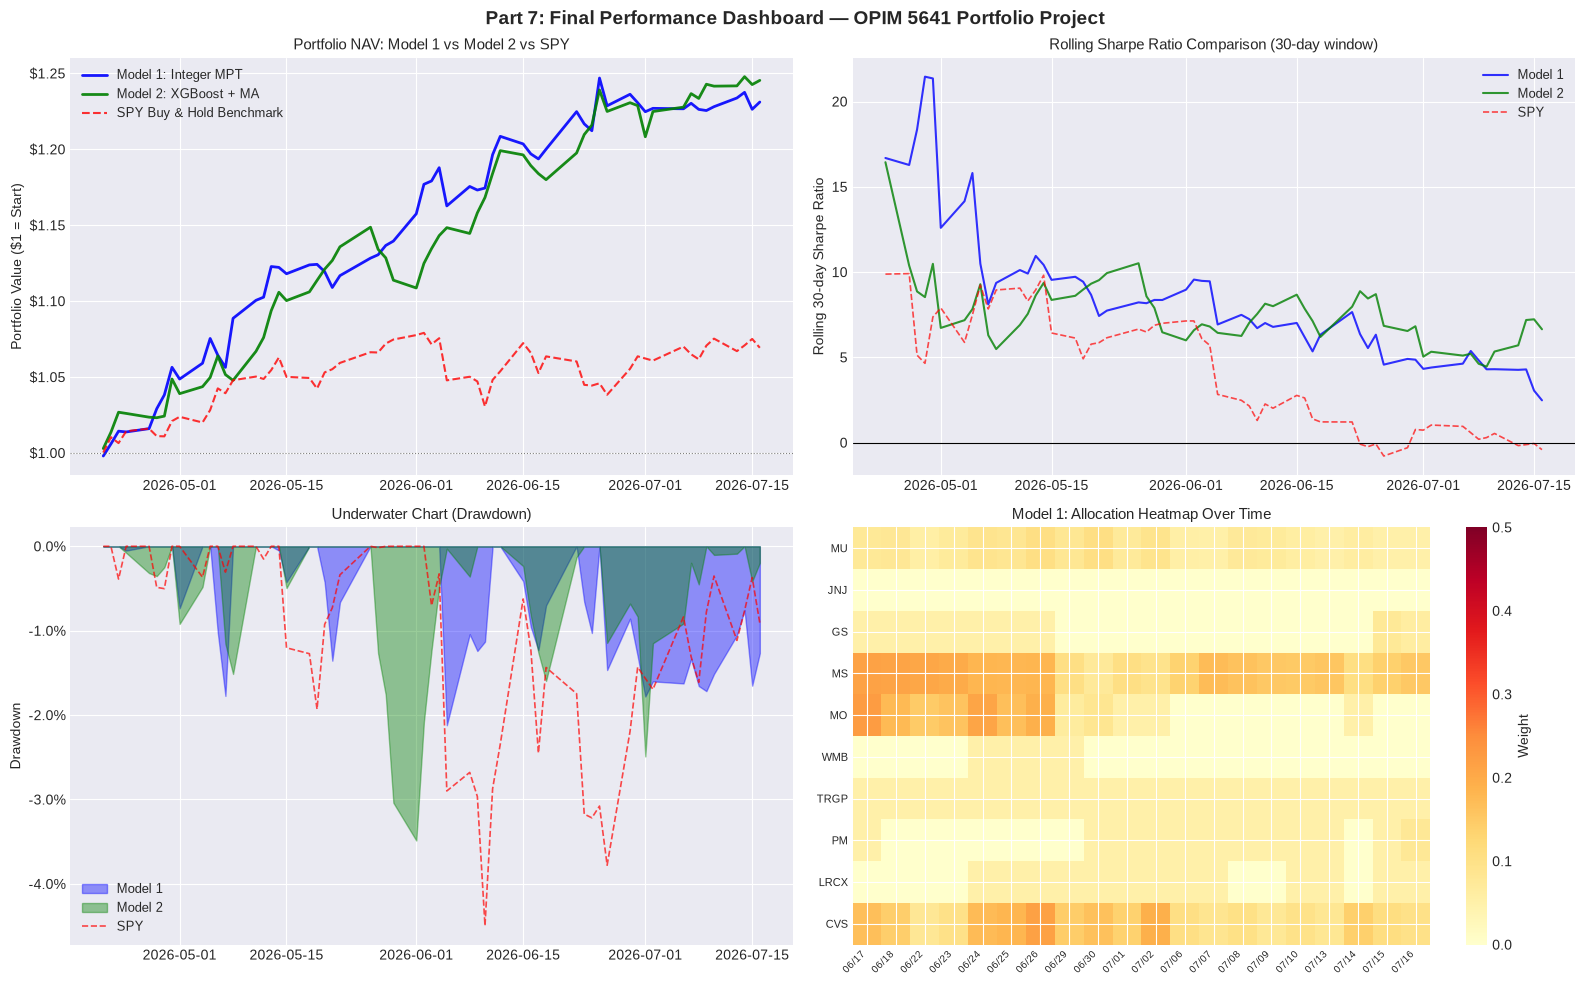

💾 Saved: final_dashboard.png


In [22]:
# ─────────────────────────────────────────────
# PLOT 5: Final Performance Dashboard
# ─────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Panel 1: NAV Growth Comparison ---
ax = axes[0, 0]
ax.plot(common_idx, nav_m1_al.values, 'b-',   lw=2,   label='Model 1: Integer MPT',   alpha=0.9)
ax.plot(common_idx, nav_m2_al.values, 'g-',   lw=2,   label='Model 2: XGBoost + MA',  alpha=0.9)
ax.plot(common_idx, spy_al.values,    'r--',  lw=1.5, label='SPY Buy & Hold Benchmark', alpha=0.8)
ax.axhline(1.0, color='gray', lw=0.8, ls=':')
ax.set_ylabel('Portfolio Value ($1 = Start)')
ax.set_title('Portfolio NAV: Model 1 vs Model 2 vs SPY', fontsize=11)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:.2f}'))

# --- Panel 2: Rolling Sharpe (adaptive until 30+ trading days exist) ---
ax = axes[0, 1]

# A 30-day rolling Sharpe is blank during the first month of forward testing.
# Use a smaller window early, then automatically expand up to 30 days.
available_returns = max(len(nav_m1_al.pct_change().dropna()),
                        len(nav_m2_al.pct_change().dropna()),
                        len(spy_al.pct_change().dropna()))
rolling_window = min(30, max(3, available_returns))
min_periods = min(3, rolling_window)

def rolling_sharpe(nav_series, window, min_periods=min_periods):
    daily = nav_series.pct_change()
    return daily.rolling(window, min_periods=min_periods).apply(
        lambda x: x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else np.nan,
        raw=False
    )

roll_sharpe_m1 = rolling_sharpe(nav_m1_al, rolling_window)
roll_sharpe_m2 = rolling_sharpe(nav_m2_al, rolling_window)
roll_sharpe_spy = rolling_sharpe(spy_al, rolling_window)

ax.plot(common_idx, roll_sharpe_m1, 'b-', lw=1.5, label='Model 1', alpha=0.8)
ax.plot(common_idx, roll_sharpe_m2, 'g-', lw=1.5, label='Model 2', alpha=0.8)
ax.plot(common_idx, roll_sharpe_spy, 'r--', lw=1.2, label='SPY', alpha=0.7)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel(f'Rolling {rolling_window}-day Sharpe Ratio')
ax.set_title(f'Rolling Sharpe Ratio Comparison ({rolling_window}-day window)', fontsize=11)
ax.legend(fontsize=9)

# --- Panel 3: Drawdown Chart ---
ax = axes[1, 0]
def get_drawdown(nav_s):
    roll_max = nav_s.cummax()
    return (nav_s - roll_max) / roll_max

dd_m1  = get_drawdown(nav_m1_al)
dd_m2  = get_drawdown(nav_m2_al)
dd_spy = get_drawdown(spy_al)
ax.fill_between(common_idx, dd_m1.values,  0, alpha=0.4, color='blue',  label='Model 1')
ax.fill_between(common_idx, dd_m2.values,  0, alpha=0.4, color='green', label='Model 2')
ax.plot(common_idx, dd_spy.values, 'r--', lw=1.2, label='SPY', alpha=0.7)
ax.set_ylabel('Drawdown')
ax.set_title('Underwater Chart (Drawdown)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.1%}'))
ax.legend(fontsize=9)

# --- Panel 4: Allocation heatmap over time ---
ax = axes[1, 1]
if alloc_m1:
    alloc_matrix = []
    alloc_dates  = []
    for entry in alloc_m1[-20:]:  # last 20 rebalances
        row = [entry['weights'].get(t, 0) for t in chosen_tickers_m1]
        alloc_matrix.append(row)
        alloc_dates.append(entry['date'].strftime('%m/%d'))

    if alloc_matrix:
        alloc_arr = np.array(alloc_matrix)
        im = ax.imshow(alloc_arr.T, aspect='auto', cmap='YlOrRd', vmin=0, vmax=0.5)
        ax.set_yticks(range(len(chosen_tickers_m1)))
        ax.set_yticklabels(chosen_tickers_m1, fontsize=8)
        ax.set_xticks(range(len(alloc_dates)))
        ax.set_xticklabels(alloc_dates, rotation=45, ha='right', fontsize=7)
        plt.colorbar(im, ax=ax, label='Weight')
        ax.set_title('Model 1: Allocation Heatmap Over Time', fontsize=11)
    else:
        ax.text(0.5, 0.5, 'Run more windows\nfor heatmap', ha='center', va='center')
else:
    ax.text(0.5, 0.5, 'No allocation history\navailable', ha='center', va='center')

plt.suptitle('Part 7: Final Performance Dashboard — OPIM 5641 Portfolio Project',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('final_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print('💾 Saved: final_dashboard.png')


# ✅ Part 8: Validation Suite & Constraint Report

In [23]:
# ---------------------------------------------
# FULL CONSTRAINT VALIDATION SUITE
# ---------------------------------------------

EPSILON = 1e-5
required_sectors = set(UNIVERSE.keys())


def validate_allocation_history(allocation_history, label):
    floor_violations = 0
    cap_violations = 0
    count_violations = 0
    sector_violations = 0
    budget_violations = 0
    windows_checked = 0
    max_budget_error = 0

    for entry in allocation_history:
        w = {t: wt for t, wt in entry['weights'].items() if wt > EPSILON}
        windows_checked += 1

        total = sum(w.values())
        error = abs(total - 1.0)
        max_budget_error = max(max_budget_error, error)
        if error > 1e-6:
            budget_violations += 1

        active = list(w.keys())
        if len(active) != N_SELECT:
            count_violations += 1

        if any(wt < MIN_ALLOC - EPSILON for wt in w.values()):
            floor_violations += 1
        if any(wt > MAX_ALLOC + EPSILON for wt in w.values()):
            cap_violations += 1

        sector_counts = pd.Series([TICKER_TO_SECTOR.get(t, 'Unknown') for t in active]).value_counts().to_dict()
        sector_ok = all(sector_counts.get(sec, 0) == MIN_PER_SECTOR for sec in required_sectors)
        if not sector_ok:
            sector_violations += 1

    if windows_checked == 0:
        raise RuntimeError(f'No allocation windows were available for validation: {label}')

    print('=' * 64)
    print(f'   {label} CONSTRAINT VALIDATION REPORT')
    print('=' * 64)
    print(f'  Trading days analyzed:            {windows_checked}')
    print(f'  Budget violations (!=1.0):        {budget_violations} ({budget_violations/windows_checked:.2%})')
    print(f'  Floor violations (<{MIN_ALLOC:.0%}):          {floor_violations} ({floor_violations/windows_checked:.2%})')
    print(f'  Cap violations (>{MAX_ALLOC:.0%}):            {cap_violations} ({cap_violations/windows_checked:.2%})')
    print(f'  Stock count violations:           {count_violations} ({count_violations/windows_checked:.2%})')
    print(f'  Sector 2-per-industry violations: {sector_violations} ({sector_violations/windows_checked:.2%})')
    print(f'  Max budget deviation:             {max_budget_error:.8f}')

    hard_violations = floor_violations + cap_violations + budget_violations + count_violations + sector_violations
    if hard_violations == 0:
        print('  ALL HARD CONSTRAINTS SATISFIED.')
    else:
        print('  Some violations found. Review solver status and fallback output.')
    print()


validate_allocation_history(alloc_m1, 'MODEL 1')
validate_allocation_history(alloc_m2, 'MODEL 2')

print('=' * 60)
print('   FORWARD-TEST SUMMARY VS BENCHMARK')
print('=' * 60)
print(metrics.to_string())


   MODEL 1 CONSTRAINT VALIDATION REPORT
  Trading days analyzed:            60
  Budget violations (!=1.0):        0 (0.00%)
  Floor violations (<5%):          0 (0.00%)
  Cap violations (>50%):            0 (0.00%)
  Stock count violations:           0 (0.00%)
  Sector 2-per-industry violations: 0 (0.00%)
  Max budget deviation:             0.00000000
  ALL HARD CONSTRAINTS SATISFIED.

   MODEL 2 CONSTRAINT VALIDATION REPORT
  Trading days analyzed:            60
  Budget violations (!=1.0):        0 (0.00%)
  Floor violations (<5%):          0 (0.00%)
  Cap violations (>50%):            0 (0.00%)
  Stock count violations:           0 (0.00%)
  Sector 2-per-industry violations: 0 (0.00%)
  Max budget deviation:             0.00000000
  ALL HARD CONSTRAINTS SATISFIED.

   FORWARD-TEST SUMMARY VS BENCHMARK
                       Total Return Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown Calmar Ratio
Strategy                                                                        

In [24]:
# Installation is handled in Part 0.
# This cell intentionally does not reinstall packages mid-notebook.


PORTFOLIO SNAPSHOT: 2026-07-16
Stocks invested:       10
Total weight:          1.000000
Sector counts:
Sector
ConsumerStaples    2
Energy             2
Financials         2
Healthcare         2
Technology         2
Average daily return:  0.35%
Portfolio value:       $123,085.07
Wealth gain since 2026-04-21: $23,085.07 (23.09%)



,Stock,Sector,Weight,Holding_Value,Stock_Return,Weighted_Return,Solver
590,KO,ConsumerStaples,0.291334,35858.855371,0.029958,0.008728,scipy_fallback
591,MS,Financials,0.150988,18584.310425,-0.044542,-0.006725,scipy_fallback
592,VLO,Energy,0.120903,14881.368377,0.025969,0.003140,scipy_fallback
593,CVS,Healthcare,0.098402,12111.777786,0.005571,0.000548,scipy_fallback
594,PM,ConsumerStaples,0.076179,9376.473120,0.049536,0.003774,scipy_fallback
595,GS,Financials,0.062195,7655.267390,-0.049138,-0.003056,scipy_fallback
596,LRCX,Technology,0.050000,6154.253279,-0.043139,-0.002157,scipy_fallback
597,MU,Technology,0.050000,6154.253279,-0.056487,-0.002824,scipy_fallback
598,TRGP,Energy,0.050000,6154.253279,0.007586,0.000379,scipy_fallback
599,ABBV,Healthcare,0.050000,6154.253279,0.042112,0.002106,scipy_fallback


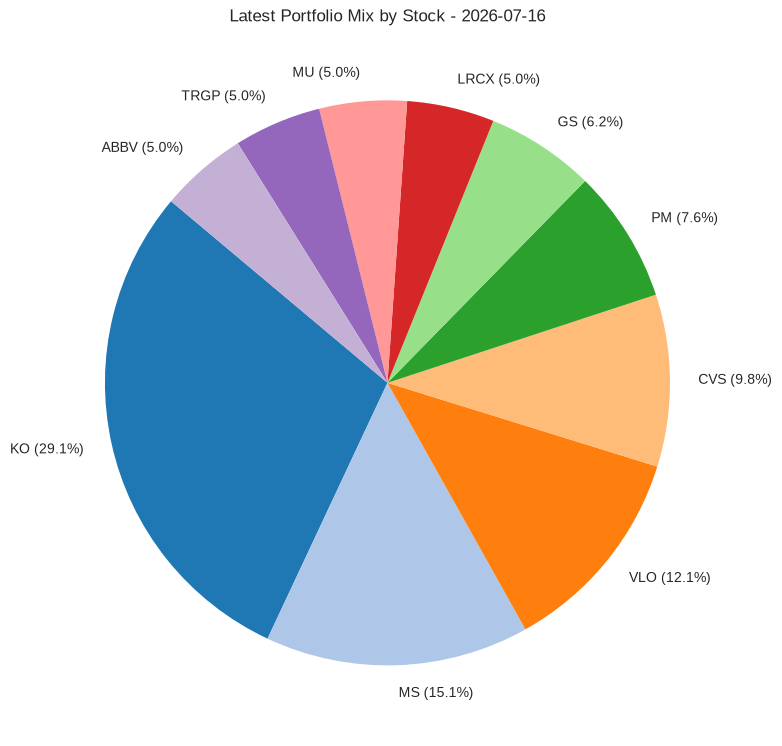

In [25]:
# ---------------------------------------------
# PORTFOLIO SUMMARY + LATEST HOLDINGS PIE CHART
# ---------------------------------------------

portfolio['Date'] = pd.to_datetime(portfolio['Date'], errors='coerce')
for col in ['Weight', 'Stock_Return', 'Weighted_Return', 'Portfolio_Return', 'Portfolio_Value', 'Holding_Value']:
    portfolio[col] = pd.to_numeric(portfolio[col], errors='coerce')

daily_summary = (
    portfolio
    .groupby('Date')
    .agg(
        Portfolio_Return=('Portfolio_Return', 'first'),
        Portfolio_Value=('Portfolio_Value', 'first'),
        NAV=('NAV', 'first'),
        Holdings=('Stock', 'nunique'),
        Total_Weight=('Weight', 'sum')
    )
    .reset_index()
    .sort_values('Date')
)
daily_summary['Cumulative_Return'] = daily_summary['NAV'] / daily_summary['NAV'].iloc[0] - 1
daily_summary['Wealth_Gain_$'] = daily_summary['Portfolio_Value'] - STARTING_WEALTH

latest_date = portfolio['Date'].max()
latest = portfolio[portfolio['Date'] == latest_date].sort_values('Weight', ascending=False).copy()

avg_daily_return = daily_summary['Portfolio_Return'].mean()
latest_value = daily_summary.loc[daily_summary['Date'] == latest_date, 'Portfolio_Value'].iloc[0]
wealth_gain = latest_value - STARTING_WEALTH
cum_return = latest_value / STARTING_WEALTH - 1

print('=' * 60)
print(f'PORTFOLIO SNAPSHOT: {latest_date.date()}')
print('=' * 60)
print(f'Stocks invested:       {len(latest)}')
print(f'Total weight:          {latest["Weight"].sum():.6f}')
print('Sector counts:')
print(latest['Sector'].value_counts().sort_index().to_string())
print(f'Average daily return:  {avg_daily_return:.2%}')
print(f'Portfolio value:       ${latest_value:,.2f}')
print(f'Wealth gain since {FORWARD_TEST_START.date()}: ${wealth_gain:,.2f} ({cum_return:.2%})')
print()

display(latest[['Stock', 'Sector', 'Weight', 'Holding_Value', 'Stock_Return', 'Weighted_Return', 'Solver']])

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    latest['Weight'],
    labels=[f'{s} ({w:.1%})' for s, w in zip(latest['Stock'], latest['Weight'])],
    startangle=140,
    autopct='',
    colors=sns.color_palette('tab20', len(latest))
)
ax.set_title(f'Latest Portfolio Mix by Stock - {latest_date.date()}')
plt.tight_layout()
plt.show()


Showing data from 2026-04-21 to 2026-07-16


,Date,Portfolio_Return,Portfolio_Value,NAV,Holdings,Total_Weight,Cumulative_Return,Wealth_Gain_$
0,2026-04-21,-0.002294,99770.608549,0.997706,10,1.0,0.000000,-229.391451
1,2026-04-22,0.007951,100563.854043,1.005639,10,1.0,0.007951,563.854043
2,2026-04-23,0.008382,101406.759026,1.014068,10,1.0,0.016399,1406.759026
3,2026-04-24,-0.000514,101354.663526,1.013547,10,1.0,0.015877,1354.663526
4,2026-04-27,0.002156,101573.165107,1.015732,10,1.0,0.018067,1573.165107
5,2026-04-28,0.012886,102882.031726,1.028820,10,1.0,0.031186,2882.031726
6,2026-04-29,0.008876,103795.162330,1.037952,10,1.0,0.040338,3795.162330
7,2026-04-30,0.017525,105614.166849,1.056142,10,1.0,0.058570,5614.166849
8,2026-05-01,-0.007349,104837.981622,1.048380,10,1.0,0.050790,4837.981622
9,2026-05-04,0.009950,105881.092611,1.058811,10,1.0,0.061245,5881.092611


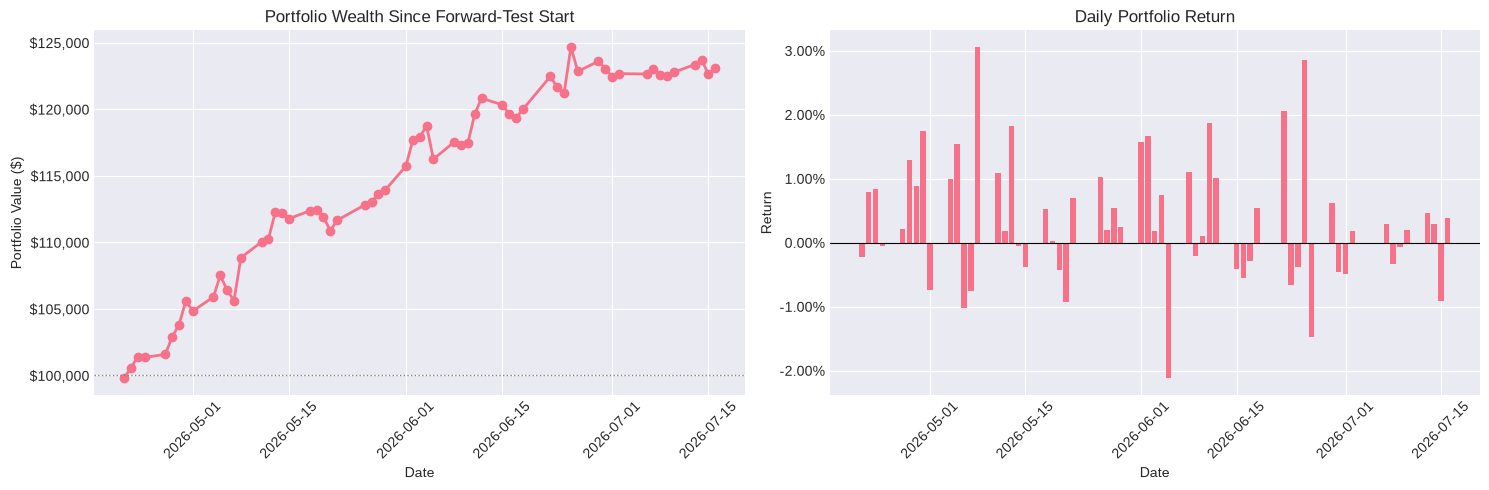

In [26]:
# ---------------------------------------------
# FINAL PORTFOLIO TIME SERIES FROM APRIL 21 FORWARD
# ---------------------------------------------

df = portfolio.copy()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df[df['Date'] >= FORWARD_TEST_START].sort_values('Date')

daily_summary = (
    df.groupby('Date')
    .agg(
        Portfolio_Return=('Portfolio_Return', 'first'),
        Portfolio_Value=('Portfolio_Value', 'first'),
        NAV=('NAV', 'first'),
        Holdings=('Stock', 'nunique'),
        Total_Weight=('Weight', 'sum')
    )
    .reset_index()
    .sort_values('Date')
)
daily_summary['Cumulative_Return'] = daily_summary['NAV'] / daily_summary['NAV'].iloc[0] - 1
daily_summary['Wealth_Gain_$'] = daily_summary['Portfolio_Value'] - STARTING_WEALTH

if daily_summary.empty:
    print(f'No data available on or after {FORWARD_TEST_START.date()}.')
else:
    print(f'Showing data from {daily_summary["Date"].min().date()} to {daily_summary["Date"].max().date()}')
    display(daily_summary)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(daily_summary['Date'], daily_summary['Portfolio_Value'], marker='o', lw=2)
    axes[0].axhline(STARTING_WEALTH, color='gray', lw=1, ls=':')
    axes[0].set_title('Portfolio Wealth Since Forward-Test Start')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Portfolio Value ($)')
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].bar(daily_summary['Date'], daily_summary['Portfolio_Return'])
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title('Daily Portfolio Return')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Return')
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2%}'))
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


In [27]:
# --- PERSIST SUMMARY TABLES FOR GITHUB ACTIONS / DASHBOARD ---

portfolio.to_csv(FORWARD_LOG_FILE, index=False)
daily_summary.to_csv('portfolio_daily_summary.csv', index=False)

latest.to_csv('latest_portfolio_holdings.csv', index=False)

print('Saved production artifacts:')
print(f'  {FORWARD_LOG_FILE}')
print('  portfolio_daily_summary.csv')
print('  latest_portfolio_holdings.csv')
display(daily_summary.tail())


Saved production artifacts:
  portfolio_forward_log.csv
  portfolio_daily_summary.csv
  latest_portfolio_holdings.csv


,Date,Portfolio_Return,Portfolio_Value,NAV,Holdings,Total_Weight,Cumulative_Return,Wealth_Gain_$
55,2026-07-10,0.002067,122778.267101,1.227783,10,1.0,0.230606,22778.267101
56,2026-07-13,0.004657,123350.076972,1.233501,10,1.0,0.236337,23350.076972
57,2026-07-14,0.003015,123721.925949,1.237219,10,1.0,0.240064,23721.925949
58,2026-07-15,-0.009024,122605.514702,1.226055,10,1.0,0.228874,22605.514702
59,2026-07-16,0.003911,123085.065585,1.230851,10,1.0,0.233681,23085.065585


In [28]:
# --- INTERACTIVE DASHBOARD (Plotly) ---

import plotly.express as px

fig1 = px.line(daily_summary, x='Date', y='Portfolio_Value', title='Portfolio Value Over Time', markers=True)
fig1.show()

fig2 = px.bar(daily_summary, x='Date', y='Portfolio_Return', title='Daily Portfolio Return')
fig2.show()

fig3 = px.line(daily_summary, x='Date', y='Cumulative_Return', title='Cumulative Return Since April 21, 2026', markers=True)
fig3.show()


In [29]:
# --- ROBUST LATEST SNAPSHOT ---

latest = portfolio[portfolio['Date'] == portfolio['Date'].max()].sort_values('Weight', ascending=False)

print('Latest 10-stock holdings snapshot:')
display(latest[['Stock', 'Sector', 'Date', 'Weight', 'Holding_Value', 'Stock_Return', 'Weighted_Return']])
print('\nLatest sector counts:')
print(latest['Sector'].value_counts().sort_index().to_string())

print(f'Average portfolio daily return since {FORWARD_TEST_START.date()}: {daily_summary["Portfolio_Return"].mean():.2%}')
print(f'Latest portfolio value: ${daily_summary["Portfolio_Value"].iloc[-1]:,.2f}')
print(f'Latest cumulative return: {daily_summary["Cumulative_Return"].iloc[-1]:.2%}')


Latest 10-stock holdings snapshot:


,Stock,Sector,Date,Weight,Holding_Value,Stock_Return,Weighted_Return
590,KO,ConsumerStaples,2026-07-16,0.291334,35858.855371,0.029958,0.008728
591,MS,Financials,2026-07-16,0.150988,18584.310425,-0.044542,-0.006725
592,VLO,Energy,2026-07-16,0.120903,14881.368377,0.025969,0.003140
593,CVS,Healthcare,2026-07-16,0.098402,12111.777786,0.005571,0.000548
594,PM,ConsumerStaples,2026-07-16,0.076179,9376.473120,0.049536,0.003774
595,GS,Financials,2026-07-16,0.062195,7655.267390,-0.049138,-0.003056
596,LRCX,Technology,2026-07-16,0.050000,6154.253279,-0.043139,-0.002157
597,MU,Technology,2026-07-16,0.050000,6154.253279,-0.056487,-0.002824
598,TRGP,Energy,2026-07-16,0.050000,6154.253279,0.007586,0.000379
599,ABBV,Healthcare,2026-07-16,0.050000,6154.253279,0.042112,0.002106



Latest sector counts:
Sector
ConsumerStaples    2
Energy             2
Financials         2
Healthcare         2
Technology         2
Average portfolio daily return since 2026-04-21: 0.35%
Latest portfolio value: $123,085.07
Latest cumulative return: 23.37%
